# Ekush Bangla Digits — Human Label Study (Notebook 2 of 2)

**Human label distributions for a stratified sample of the Ekush numeral test set**

---

This notebook reads the frozen study package written by Notebook 1 (`Ekush_Model_Analysis.ipynb`) from the shared Drive folder, and imports the same `ekush_core.py` module. It collects label *distributions* from a human panel and re-evaluates the benchmark against them. It never trains a benchmark model and never re-selects items. Every package file is verified against its SHA-256 before anything runs.

## Two passes, with people in between

**Pass A (sections 1–3).** Verifies the package and the images, builds the offline annotation tool, and stops. Send `annotation_package.zip` to annotators A01…A10.

Everything it produces (tables, figures, release files, the annotation tool) is written to `MyDrive/ekush_study/human_study/`, so nothing is lost when a Colab session ends. Annotation CSVs go in that folder's `annotations/` subfolder.

**Pass B (sections 4–13).** Put the returned CSVs in `ekush_human_study/annotations/` and run all. The analysis covers:

- annotator reliability and noise;
- human-support estimates for the Ekush labels;
- **precision of Notebook 1's label-issue candidates**;
- model rankings against human labels, and distributional metrics;
- perspectivist structure tests;
- annotator saturation;
- agreement-conditioned benchmarking;
- cross-validated soft-label training;
- the dataset release.

## Guardrails (publication mode)

The run stops if any of the following occurs:

- a package file or image does not match its recorded hash;
- a CSV comes from a different tool build, contains unknown items, or repeats an annotator;
- fewer than the pre-registered number of annotators pass the exclusion rules;
- the soft-label checkpoint does not match its recorded hash.

The thresholds are read from the package, so they cannot be edited here.

Simulation exists only for debugging (`debug_simulate=True`). It writes to a separate `_DEBUG` folder, and every output there is stamped SIMULATED.

## 1. Environment and Configuration

In [1]:
import importlib, subprocess, sys
REQUIRED = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib",
            "seaborn": "seaborn", "sklearn": "scikit-learn", "scipy": "scipy",
            "PIL": "pillow", "tqdm": "tqdm"}
missing = [p for m, p in REQUIRED.items() if importlib.util.find_spec(m) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
print("Dependencies ready.")

Dependencies ready.


In [2]:
import os, json, time, math, random, base64, hashlib, shutil, platform, warnings, zipfile
import urllib.request
from dataclasses import dataclass, asdict, field
from pathlib import Path
from collections import Counter, defaultdict
from io import BytesIO
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import tensorflow as tf
import keras

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import confusion_matrix
from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# The Drive study folder holds ekush_core.py, the study package and the models.
DRIVE_ROOT = os.environ.get("EKUSH_DRIVE_ROOT", "/content/drive/MyDrive/ekush_study")
if "google.colab" in sys.modules:
    from google.colab import drive as _drive
    if not Path("/content/drive/MyDrive").is_dir():
        _drive.mount("/content/drive")
Path(DRIVE_ROOT).mkdir(parents=True, exist_ok=True)
sys.path.insert(0, DRIVE_ROOT)
try:
    import ekush_core as ek
except ModuleNotFoundError:
    raise SystemExit(f"ekush_core.py not found in {DRIVE_ROOT}. Upload it there and re-run.")
import importlib as _il
ek = _il.reload(ek)

# Shared helpers come from the module; only study-specific code lives here.
StopExecution = ek.StopExecution
wilson, fmt_ci, entropy = ek.wilson, ek.fmt_ci, ek.entropy
sha256_file, rel_key, set_seed = ek.sha256_file, ek.rel_key, ek.set_seed
to_latex_simple = ek.to_latex_simple
BANGLA_DIGITS, DIGIT_CLASSES, PALETTE = ek.BANGLA_DIGITS, ek.DIGIT_CLASSES, ek.PALETTE
DISPLAY_NAMES = ek.DISPLAY_NAMES
ek.style_plots()

print(f"ekush_core {ek.__version__} | Python {platform.python_version()} | "
      f"TensorFlow {tf.__version__} | Keras {keras.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU') or 'none (CPU only)'}")
print(f"Study folder: {DRIVE_ROOT}")

Mounted at /content/drive
ekush_core 1.0 | Python 3.13.15 | TensorFlow 2.20.0 | Keras 3.13.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Study folder: /content/drive/MyDrive/ekush_study


In [3]:
@dataclass
class Config:
    # ---------------------------------------------------------------- run mode
    publication_mode: bool = True
    debug_simulate: bool = False

    # ------------------------------------------------ inputs from Notebook 1
    package_zip: str = ""        # defaults to <drive>/study_package.zip
    models_dir: str = ""         # defaults to <drive>/models (checkpoints from Notebook 1)
    local_scratch: str = "/content/ekush_local"
    # Published accuracies to plot next to the human-support estimate.
    # VERIFY each value against the cited paper; empty on purpose.
    literature_accuracies: dict = field(default_factory=dict)

    # ------------------------------------------------------ annotation tool
    display_px: int = 140

    # -------------------------------------------------------------- statistics
    n_bootstrap: int = 5000
    n_bootstrap_rank: int = 2000
    n_permutations: int = 1000
    saturation_reps: int = 50
    alpha_level: float = 0.05
    stats_seed: int = 2026

    # ------------------------------------------------------ soft-label training
    run_soft_training: bool = True
    soft_cv_folds: int = 5
    soft_seeds: tuple = (13, 42, 2024)
    soft_epochs: int = 15
    soft_lr: float = 1e-4
    soft_batch: int = 32

    drive_root: str = ""         # set from DRIVE_ROOT below
    output_dir: str = ""         # defaults to <drive>/human_study

    def __post_init__(self):
        self.drive_root = self.drive_root or DRIVE_ROOT
        self.package_zip = self.package_zip or str(Path(self.drive_root) / "study_package.zip")
        self.models_dir = self.models_dir or str(Path(self.drive_root) / "models")
        self.output_dir = self.output_dir or str(Path(self.drive_root) / "human_study")
        if self.debug_simulate:
            self.output_dir = self.output_dir + "_DEBUG"
            self.publication_mode = False

    @property
    def image_tree(self):
        return str(Path(self.local_scratch) / "data" / "ekush_digits")

    @property
    def figures_dir(self): return str(Path(self.output_dir) / "figures")
    @property
    def tables_dir(self): return str(Path(self.output_dir) / "tables")
    @property
    def annot_dir(self): return str(Path(self.output_dir) / "annotations")
    @property
    def release_dir(self): return str(Path(self.output_dir) / "release")
    @property
    def frozen_dir(self): return str(Path(self.output_dir) / "package")


CFG = Config()
for d in (CFG.figures_dir, CFG.tables_dir, CFG.annot_dir, CFG.release_dir, CFG.frozen_dir):
    Path(d).mkdir(parents=True, exist_ok=True)

MODE = "SIMULATED — DEBUG ONLY, NOT PUBLISHABLE" if CFG.debug_simulate else "REAL DATA"
Q_COLS = [f"q_{c}" for c in DIGIT_CLASSES]


def savefig(fig, name):
    if CFG.debug_simulate:
        fig.text(0.5, 0.5, "SIMULATED", fontsize=60, color="red", alpha=0.18,
                 ha="center", va="center", rotation=30, transform=fig.transFigure)
    for ext in ("png", "pdf"):
        fig.savefig(Path(CFG.figures_dir) / f"{name}.{ext}", dpi=300, bbox_inches="tight")
    return fig

def fail(msg):
    if CFG.publication_mode:
        raise StopExecution("STOPPED (publication mode): " + msg)
    print("WARNING (debug mode, would stop in publication mode): " + msg)

print(f"Mode: {MODE} | publication_mode={CFG.publication_mode}")
print(f"Output directory: {CFG.output_dir}")
print(f"Study package: {CFG.package_zip}")

Mode: REAL DATA | publication_mode=True
Output directory: /content/drive/MyDrive/ekush_study/human_study
Study package: /content/drive/MyDrive/ekush_study/study_package.zip


## 2. Verify the Study Package and the Images

The package is unpacked and every file is checked against the hashes in `package_manifest.json`. The Ekush images are then located, or downloaded again from the same public mirror, and **every test image is checked against its MD5**. This guarantees that the images annotators see are exactly the ones Notebook 1 evaluated.

In [4]:
PKG_DIR = Path(CFG.frozen_dir)
if not Path(CFG.package_zip).is_file():
    raise StopExecution(f"STOPPED: study package not found at {CFG.package_zip}. "
                        "Run Notebook 1 first and copy study_package.zip here.")
with zipfile.ZipFile(CFG.package_zip) as zf:
    zf.extractall(PKG_DIR)
PKG = json.loads((PKG_DIR / "package_manifest.json").read_text())
bad = [f for f, h in PKG["files"].items() if sha256_file(PKG_DIR / f) != h]
if bad:
    raise StopExecution(f"STOPPED: package files do not match their hashes: {bad}")

PREREG = PKG["preregistration"]
if hashlib.sha256(json.dumps(PREREG, indent=2, sort_keys=True).encode()).hexdigest() \
        != PKG["preregistration_sha256"]:
    raise StopExecution("STOPPED: pre-registration hash mismatch.")
for k, v in PREREG.items():          # thresholds come only from the package
    setattr(CFG, k, v)

INSTRUMENT_ID = PKG["study_id"]
TEST_SPLIT_SHA = PKG["test_split_sha256"]
SPLIT_PROVENANCE = f"Notebook 1 study package {INSTRUMENT_ID}"
STRATUM_POPULATION = PKG["stratum_population"]
STRATA = [s for s in ["cl", "high", "mid", "low"] if STRATUM_POPULATION.get(s, 0) > 0]
N = PKG["n_test"]
STRATUM_WEIGHT = {s: STRATUM_POPULATION[s] / N for s in STRATA}
FROZEN = {"preregistration": PREREG,
          "preregistration_sha256": PKG["preregistration_sha256"],
          "member_preprocessing": {"all": PKG["input"]},
          "created_utc": PKG["created_utc"]}

print(f"Package verified: study {INSTRUMENT_ID}, frozen {PKG['created_utc']}")
print(f"Strata (population): {STRATUM_POPULATION}  (sum = {sum(STRATUM_POPULATION.values())}, N = {N})")
print("Pre-registered thresholds:")
print(json.dumps(PREREG, indent=2))

Package verified: study b12741b6c6a57544, frozen 2026-09-19T06:03:15Z
Strata (population): {'cl': 2, 'high': 600, 'mid': 600, 'low': 1822}  (sum = 3024, N = 3024)
Pre-registered thresholds:
{
  "n_cl_max": 100,
  "n_high": 600,
  "mid_pool_size": 600,
  "n_mid": 200,
  "n_low": 200,
  "attention_check_frac": 0.05,
  "selection_seed": 7,
  "n_annotators_expected": 10,
  "min_annotators_retained": 6,
  "min_repeat_consistency": 0.6,
  "min_control_accuracy": 0.85,
  "min_completeness": 0.98,
  "fast_response_ms": 700,
  "max_fast_rate": 0.2,
  "unambiguous_max_dissent": 1,
  "min_digit_votes": 5,
  "illegible_threshold": 0.5,
  "mislabel_threshold": 0.8,
  "noise_test_alpha": 0.05
}


In [5]:
# Images are rebuilt on local disk from the dataset arrays cached on Drive by
# Notebook 1, so nothing is re-downloaded.
CORE_CFG = ek.Config(drive_root=CFG.drive_root, local_scratch=CFG.local_scratch,
                     mount_drive=False)
tree = Path(ek.acquire_dataset(CORE_CFG, progress=tqdm))

test_split = pd.read_csv(PKG_DIR / "test_split.csv")
test_split["filepath"] = [str(tree / k) for k in test_split["rel_key"]]
mism = [k for k, p, h in zip(test_split["rel_key"], test_split["filepath"], test_split["md5"])
        if not Path(p).is_file() or hashlib.md5(open(p, "rb").read()).hexdigest() != h]
if mism:
    raise StopExecution(f"STOPPED: {len(mism)} test images are missing or differ from "
                        f"Notebook 1 (e.g. {mism[:3]}).")
y_test = test_split["class_idx"].to_numpy()
print(f"All {len(test_split):,} test images verified against Notebook 1 hashes.")

Using cached dataset arrays from /content/drive/MyDrive/ekush_study/dataset_cache


Writing PNGs:   0%|          | 0/30687 [00:00<?, ?it/s]

Materialised 30,687 images at /content/ekush_local/data/ekush_digits
All 3,024 test images verified against Notebook 1 hashes.


[REAL DATA]  Seed-averaged test accuracy (n = 3,024), from Notebook 1 predictions

                Test accuracy  95% CI low  95% CI high  Errors  Params (M)
Model                                                                     
xception               0.9940      0.9906       0.9962      18     20.8820
resnet50v2             0.9964      0.9935       0.9980      11     23.5853
mobilenetv2            0.9954      0.9922       0.9972      14      2.2708
efficientnetb0         0.9904      0.9863       0.9933      29      4.0624
custom_cnn             0.9931      0.9894       0.9955      21      0.2891
ENSEMBLE MEAN          0.9967      0.9939       0.9982      10         NaN

           n  mean_ambiguity
stratum                     
cl         2          0.4592
high     600          0.8234
low      200          0.3439
mid      200          0.6432

Items: 1,002 | attention checks: 50 | study ID: b12741b6c6a57544


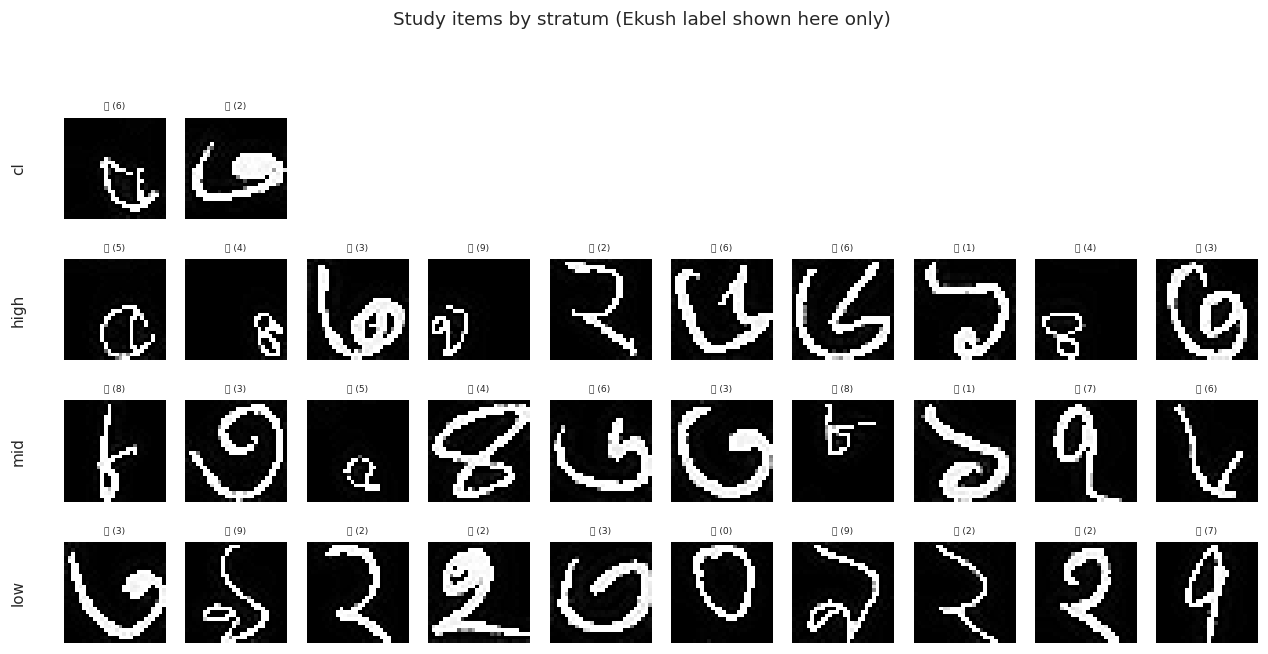

In [6]:
items = pd.read_csv(PKG_DIR / "items.csv")
items["item_index"] = items["test_position"].astype(int)
items["filepath"] = test_split.loc[items["item_index"], "filepath"].to_numpy()
assert (items["rel_key"].to_numpy() == test_split.loc[items["item_index"], "rel_key"].to_numpy()).all()
check_uids = json.loads((PKG_DIR / "attention_checks.json").read_text())
cl_candidates_test = pd.read_csv(PKG_DIR / "test_label_issue_candidates.csv")

UID_TO_STRATUM = dict(zip(items["item_uid"], items["stratum"]))
UID_TO_LABEL = dict(zip(items["item_uid"], items["ekush_label"].astype(int)))
UID_TO_INDEX = dict(zip(items["item_uid"], items["item_index"].astype(int)))

# Model-level predictions: each architecture is the mean of its seeds.
runs = pd.read_csv(PKG_DIR / "runs.csv")
probs_npz = np.load(PKG_DIR / "test_probs.npz")
run_probs = {r: probs_npz[r] for r in runs["run"]}
member_probs = {a: np.mean([run_probs[r] for r in runs.loc[runs["arch"] == a, "run"]], axis=0)
                for a in PKG["architectures"]}
MEMBERS = list(member_probs)
p_bar = np.mean([run_probs[r] for r in runs["run"]], axis=0)
HEADLINE_TAG = PKG["headline_arch"]
ENSEMBLE_SOURCE = (f"Notebook 1 runs: {len(runs)} ({len(MEMBERS)} architectures x "
                   f"{len(PKG['seeds'])} seeds); models are seed-averaged")

acc_rows = []
for t in MEMBERS + ["ENSEMBLE MEAN"]:
    pr = (p_bar if t == "ENSEMBLE MEAN" else member_probs[t]).argmax(1)
    k = int((pr == y_test).sum()); lo, hi = wilson(k, N)
    params = runs.loc[runs["arch"] == t, "params"]
    acc_rows.append({"Model": t, "Test accuracy": k / N, "95% CI low": lo, "95% CI high": hi,
                     "Errors": N - k,
                     "Params (M)": params.iloc[0] / 1e6 if len(params) else np.nan})
member_test_acc = pd.DataFrame(acc_rows).set_index("Model")
member_test_acc.to_csv(Path(CFG.tables_dir) / "table_member_test_accuracy.csv")
print(f"[{MODE}]  Seed-averaged test accuracy (n = {N:,}), from Notebook 1 predictions\n")
print(member_test_acc.round(4).to_string())
print()
print(items.groupby("stratum").agg(n=("item_uid", "count"),
                                   mean_ambiguity=("ambiguity_rank", "mean")).round(4).to_string())
print(f"\nItems: {len(items):,} | attention checks: {len(check_uids)} | study ID: {INSTRUMENT_ID}")

fig, axes = plt.subplots(len(STRATA), 10, figsize=(14, 1.6 * len(STRATA)), squeeze=False)
for r_, s in enumerate(STRATA):
    pool = items[items["stratum"] == s].head(10)
    for c_ in range(10):
        ax = axes[r_, c_]; ax.axis("off")
        if c_ < len(pool):
            row = pool.iloc[c_]
            ax.imshow(Image.open(row["filepath"]).convert("L"), cmap="gray")
            ax.set_title(f"{DISPLAY_NAMES[int(row['ekush_label'])]}", fontsize=6)
    axes[r_, 0].text(-0.45, 0.5, s, transform=axes[r_, 0].transAxes, rotation=90,
                     va="center", ha="center", fontsize=10)
fig.suptitle("Study items by stratum (Ekush label shown here only)", y=1.02)
savefig(fig, "hfig01_items_by_stratum")
plt.show()

## 3. The Annotation Instrument

The instrument is a single offline HTML file, designed as follows:

- **Blinded:** opaque item IDs, no stored label and no model output.
- **Order:** randomised separately for each annotator.
- **Confidence:** a rating is required for every answer.
- **Escape options:** "illegible" and "not a digit".
- **Logging:** response times are recorded.
- **Convenience:** autosave and keyboard controls.

Every exported row carries the study ID, and Pass B rejects rows produced by any other build of the tool.

In [7]:
def encode_item(path, size=28):
    """Embed at native resolution; the browser scales it up with CSS.

    Embedding 28x28 rather than an upscaled bitmap keeps the whole instrument
    around 1 MB instead of 5 MB, which matters when annotators download it
    over mobile connections.
    """
    im = Image.open(path).convert("L")
    if im.size != (size, size):
        im = im.resize((size, size), Image.LANCZOS)
    buf = BytesIO()
    im.save(buf, format="PNG", optimize=True)
    return base64.b64encode(buf.getvalue()).decode("ascii")


payload = []
for _, row in tqdm(items.iterrows(), total=len(items),
                   desc="Encoding items", leave=False):
    payload.append({"uid": row["item_uid"], "img": encode_item(row["filepath"])})

payload_json = json.dumps(payload, separators=(",", ":"))
checks_json = json.dumps(check_uids, separators=(",", ":"))
print(f"Encoded payload: {len(payload_json) / 1e6:.2f} MB "
      f"for {len(payload):,} items")

Encoding items:   0%|          | 0/1002 [00:00<?, ?it/s]

Encoded payload: 0.58 MB for 1,002 items


In [8]:
INSTRUMENT_HTML = r"""<!DOCTYPE html>
<html lang="bn">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Bangla Digit Annotation Study</title>
<style>
  :root { --bg:#f7f7f8; --card:#fff; --ink:#1a1a1a; --mut:#6b6b70;
          --line:#dcdce0; --accent:#2b6cb0; --warn:#b7791f; }
  * { box-sizing:border-box; }
  body { margin:0; background:var(--bg); color:var(--ink);
         font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,sans-serif; }
  .wrap { max-width:860px; margin:0 auto; padding:18px 16px 60px; }
  .card { background:var(--card); border:1px solid var(--line);
          border-radius:10px; padding:20px; margin-bottom:14px; }
  h1 { font-size:19px; margin:0 0 4px; }
  h2 { font-size:15px; margin:18px 0 8px; }
  .mut { color:var(--mut); font-size:13px; line-height:1.55; }
  .bar { height:6px; background:var(--line); border-radius:3px; overflow:hidden; }
  .bar > div { height:100%; background:var(--accent); width:0%; transition:width .2s; }
  .stat { display:flex; justify-content:space-between; font-size:12px;
          color:var(--mut); margin-top:6px; }
  .stage { display:flex; justify-content:center; align-items:center;
           padding:26px 0; }
  .stage img { width:PLACEHOLDER_PXpx; height:PLACEHOLDER_PXpx;
               image-rendering:auto; border:1px solid var(--line);
               background:#000; border-radius:6px; }
  .grid { display:grid; grid-template-columns:repeat(5,1fr); gap:8px; }
  button { font:inherit; cursor:pointer; border:1px solid var(--line);
           background:#fff; border-radius:8px; padding:10px 6px;
           transition:.12s; }
  button:hover { border-color:var(--accent); }
  .digit { font-size:26px; line-height:1.15; }
  .digit small { display:block; font-size:11px; color:var(--mut); }
  .sel { background:var(--accent); color:#fff; border-color:var(--accent); }
  .sel small { color:#dbeafe; }
  .row { display:grid; grid-template-columns:1fr 1fr; gap:8px; margin-top:8px; }
  .conf { display:grid; grid-template-columns:repeat(3,1fr); gap:8px; }
  .nav { display:flex; gap:8px; margin-top:14px; }
  .nav button { flex:1; padding:12px; }
  .primary { background:var(--accent); color:#fff; border-color:var(--accent);
             font-weight:600; }
  .primary:disabled { background:#c3c9d2; border-color:#c3c9d2; cursor:not-allowed; }
  input { font:inherit; padding:9px 11px; border:1px solid var(--line);
          border-radius:7px; width:230px; }
  kbd { background:#eef0f3; border:1px solid var(--line); border-bottom-width:2px;
        border-radius:4px; padding:1px 5px; font-size:11px; font-family:monospace; }
  .hide { display:none; }
  .note { background:#fffbeb; border:1px solid #fde68a; border-radius:8px;
          padding:10px 12px; font-size:13px; color:#78350f; }
</style>
</head>
<body>
<div class="wrap">

  <!-- ============ CONSENT / START ============ -->
  <div id="start" class="card">
    <h1>বাংলা অঙ্ক লেবেলিং গবেষণা / Bangla Digit Annotation Study</h1>
    <p class="mut">
      <b>বাংলা:</b> আপনাকে হাতে লেখা বাংলা অঙ্কের ছবি একটি একটি করে দেখানো হবে।
      প্রতিটি ছবির জন্য আপনার মনে হওয়া অঙ্কটি বেছে নিন এবং আপনি কতটা নিশ্চিত তা জানান।
      কিছু ছবি অস্পষ্ট হতে পারে — এটাই স্বাভাবিক এবং এটাই আমাদের গবেষণার মূল বিষয়।
      অনুমান করতে দ্বিধা করবেন না, তবে সৎভাবে আপনার আত্মবিশ্বাসের মাত্রা জানান।
      পড়া একেবারেই সম্ভব না হলে <b>অস্পষ্ট</b> বেছে নিন।
    </p>
    <p class="mut">
      <b>English:</b> You will see handwritten Bangla digits one at a time. For each,
      choose the digit you think it is and state how confident you are. Some images
      are genuinely unclear — that is expected and is precisely what this study
      measures. Guessing is fine, but report your confidence honestly. Use
      <b>Illegible</b> when the image cannot be read at all, and <b>Not a digit</b>
      if it is not a numeral.
    </p>
    <div class="note">
      অন্য কারও সাথে আলোচনা করবেন না। প্রতিটি উত্তর স্বাধীন হতে হবে। &nbsp;|&nbsp;
      Please do not discuss items with other annotators — independence is essential.
    </div>
    <h2>Annotator ID</h2>
    <p class="mut">Use the identifier given to you (e.g. <code>A03</code>).
       It seeds your personal item order, so enter it exactly.</p>
    <input id="aid" placeholder="A01" autocomplete="off">
    <div class="nav">
      <button class="primary" onclick="begin()">শুরু করুন / Begin</button>
    </div>
    <p class="mut" style="margin-top:14px">
      Keyboard: <kbd>0</kbd>–<kbd>9</kbd> digit &nbsp;
      <kbd>i</kbd> illegible &nbsp; <kbd>n</kbd> not a digit &nbsp;
      <kbd>c</kbd>/<kbd>p</kbd>/<kbd>g</kbd> confidence &nbsp;
      <kbd>Enter</kbd> next
    </p>
  </div>

  <!-- ============ TASK ============ -->
  <div id="task" class="card hide">
    <div class="bar"><div id="prog"></div></div>
    <div class="stat">
      <span id="counter">0 / 0</span>
      <span id="who"></span>
      <span id="saved">saved</span>
    </div>

    <div class="stage"><img id="img" alt="handwritten digit"></div>

    <h2>এটি কোন অঙ্ক? / Which digit is this?</h2>
    <div class="grid" id="digits"></div>
    <div class="row">
      <button id="bIll" onclick="pick('illegible')">অস্পষ্ট / Illegible <kbd>i</kbd></button>
      <button id="bNot" onclick="pick('not_digit')">অঙ্ক নয় / Not a digit <kbd>n</kbd></button>
    </div>

    <h2>কতটা নিশ্চিত? / How confident?</h2>
    <div class="conf">
      <button id="cCertain"  onclick="conf('certain')">নিশ্চিত / Certain <kbd>c</kbd></button>
      <button id="cProbable" onclick="conf('probable')">সম্ভবত / Probable <kbd>p</kbd></button>
      <button id="cGuess"    onclick="conf('guess')">অনুমান / Guess <kbd>g</kbd></button>
    </div>

    <div class="nav">
      <button onclick="back()">← পূর্ববর্তী / Back</button>
      <button id="next" class="primary" onclick="next()" disabled>
        পরবর্তী / Next <kbd>Enter</kbd></button>
    </div>
    <div class="nav">
      <button onclick="exportCsv()">অগ্রগতি সংরক্ষণ / Export progress (CSV)</button>
    </div>
  </div>

  <!-- ============ DONE ============ -->
  <div id="done" class="card hide">
    <h1>সম্পন্ন! / Complete</h1>
    <p class="mut">ধন্যবাদ। নিচের বোতামে ক্লিক করে CSV ফাইলটি নামিয়ে গবেষকের কাছে পাঠান।<br>
       Thank you. Download the CSV below and send it to the researcher.</p>
    <div class="nav">
      <button class="primary" onclick="exportCsv()">Download CSV</button>
    </div>
  </div>

</div>

<script>
const ITEMS  = PLACEHOLDER_ITEMS;
const CHECKS = PLACEHOLDER_CHECKS;
const INSTRUMENT_ID = "PLACEHOLDER_IID";
const BN = ["\u09E6","\u09E7","\u09E8","\u09E9","\u09EA",
            "\u09EB","\u09EC","\u09ED","\u09EE","\u09EF"];

let order = [], idx = 0, resp = {}, aid = "", shownAt = 0;

function hashSeed(s){ let h=2166136261>>>0;
  for(let i=0;i<s.length;i++){ h^=s.charCodeAt(i); h=Math.imul(h,16777619)>>>0; }
  return h>>>0; }
function mulberry(a){ return function(){ a|=0; a=a+0x6D2B79F5|0;
  let t=Math.imul(a^a>>>15,1|a); t=t+Math.imul(t^t>>>7,61|t)^t;
  return ((t^t>>>14)>>>0)/4294967296; }; }

function buildOrder(seed){
  // Base order: every item once, shuffled per annotator.
  const rnd = mulberry(hashSeed(seed));
  let base = ITEMS.map((it,i)=>({uid:it.uid, i:i, rep:0}));
  for(let i=base.length-1;i>0;i--){ const j=Math.floor(rnd()*(i+1));
    [base[i],base[j]]=[base[j],base[i]]; }
  // Attention checks reappear in the final third, far from first presentation.
  const idxOf = {}; ITEMS.forEach((it,i)=>idxOf[it.uid]=i);
  const reps = CHECKS.map(u=>({uid:u, i:idxOf[u], rep:1}));
  for(let i=reps.length-1;i>0;i--){ const j=Math.floor(rnd()*(i+1));
    [reps[i],reps[j]]=[reps[j],reps[i]]; }
  const cut = Math.floor(base.length*0.66);
  const head = base.slice(0,cut), tail = base.slice(cut);
  reps.forEach(r=>{ tail.splice(Math.floor(rnd()*(tail.length+1)),0,r); });
  return head.concat(tail);
}

function storeKey(){ return "bnDigitAnnot_"+INSTRUMENT_ID+"_"+aid; }
function save(){ try{ localStorage.setItem(storeKey(),
    JSON.stringify({idx:idx, resp:resp})); document.getElementById("saved")
    .textContent="saved "+new Date().toLocaleTimeString(); }catch(e){} }
function load(){ try{ const r=localStorage.getItem(storeKey());
    if(r){ const d=JSON.parse(r); idx=d.idx||0; resp=d.resp||{}; return true; }
  }catch(e){} return false; }

function begin(){
  aid = document.getElementById("aid").value.trim();
  if(!aid){ alert("Please enter your annotator ID."); return; }
  order = buildOrder(aid);
  const resumed = load();
  if(resumed && idx>0 && !confirm(
      "Previous session found at item "+(idx+1)+". Continue from there?\n"+
      "(Cancel restarts from the beginning.)")){ idx=0; resp={}; }
  document.getElementById("start").classList.add("hide");
  document.getElementById("task").classList.remove("hide");
  document.getElementById("who").textContent = "annotator "+aid+" | build "+INSTRUMENT_ID;
  render();
}

function key(k){ return k.uid+"__r"+k.rep; }

function render(){
  if(idx>=order.length){
    document.getElementById("task").classList.add("hide");
    document.getElementById("done").classList.remove("hide"); save(); return; }
  const cur = order[idx];
  document.getElementById("img").src = "data:image/png;base64,"+ITEMS[cur.i].img;
  document.getElementById("counter").textContent = (idx+1)+" / "+order.length;
  document.getElementById("prog").style.width = (100*idx/order.length)+"%";

  const g = document.getElementById("digits"); g.innerHTML="";
  for(let d=0; d<10; d++){
    const b=document.createElement("button");
    b.className="digit"; b.id="d"+d;
    b.innerHTML = BN[d]+"<small>"+d+"</small>";
    b.onclick = ()=>pick(String(d));
    g.appendChild(b);
  }
  const r = resp[key(cur)] || {};
  if(r.response!==undefined) mark(r.response);
  if(r.confidence!==undefined) markConf(r.confidence);
  document.getElementById("next").disabled =
    !(r.response!==undefined && r.confidence!==undefined);
  shownAt = performance.now();
}

function clearSel(){
  for(let d=0; d<10; d++){ const e=document.getElementById("d"+d);
    if(e) e.classList.remove("sel"); }
  ["bIll","bNot"].forEach(i=>document.getElementById(i).classList.remove("sel"));
}
function mark(v){ clearSel();
  const e = (v==="illegible")?document.getElementById("bIll")
          :(v==="not_digit")?document.getElementById("bNot")
          :document.getElementById("d"+v);
  if(e) e.classList.add("sel"); }
function markConf(c){
  ["cCertain","cProbable","cGuess"].forEach(i=>
    document.getElementById(i).classList.remove("sel"));
  const m={certain:"cCertain",probable:"cProbable",guess:"cGuess"};
  if(m[c]) document.getElementById(m[c]).classList.add("sel"); }

function pick(v){
  const k=key(order[idx]);
  resp[k] = Object.assign({}, resp[k], {response:v,
            response_ms: Math.round(performance.now()-shownAt)});
  // An illegible or non-digit judgement is itself a certain judgement.
  if((v==="illegible"||v==="not_digit") && !resp[k].confidence){
    resp[k].confidence="certain"; markConf("certain"); }
  mark(v); checkReady(); save(); }

function conf(c){
  const k=key(order[idx]);
  resp[k] = Object.assign({}, resp[k], {confidence:c});
  markConf(c); checkReady(); save(); }

function checkReady(){
  const r = resp[key(order[idx])] || {};
  document.getElementById("next").disabled =
    !(r.response!==undefined && r.confidence!==undefined); }

function next(){ if(document.getElementById("next").disabled) return;
  idx++; save(); render(); }
function back(){ if(idx>0){ idx--; render(); } }

document.addEventListener("keydown", e=>{
  if(document.getElementById("task").classList.contains("hide")) return;
  if(e.key>="0" && e.key<="9"){ pick(e.key); e.preventDefault(); }
  else if(e.key==="i"){ pick("illegible"); }
  else if(e.key==="n"){ pick("not_digit"); }
  else if(e.key==="c"){ conf("certain"); }
  else if(e.key==="p"){ conf("probable"); }
  else if(e.key==="g"){ conf("guess"); }
  else if(e.key==="Enter"){ next(); e.preventDefault(); }
  else if(e.key==="Backspace"){ back(); e.preventDefault(); }
});

function exportCsv(){
  const rows=[["annotator_id","item_uid","repeat","presentation_index",
               "response","confidence","response_ms","instrument_id"].join(",")];
  order.forEach((o,pi)=>{ const r=resp[key(o)];
    if(r && r.response!==undefined){
      rows.push([aid,o.uid,o.rep,pi,r.response,r.confidence||"",
                 r.response_ms||"",INSTRUMENT_ID].join(",")); } });
  const blob=new Blob([rows.join("\n")],{type:"text/csv;charset=utf-8;"});
  const a=document.createElement("a");
  a.href=URL.createObjectURL(blob);
  a.download="annotations_"+aid+".csv"; a.click();
}
</script>
</body>
</html>
"""

html = (INSTRUMENT_HTML
        .replace("PLACEHOLDER_ITEMS", payload_json)
        .replace("PLACEHOLDER_CHECKS", checks_json)
        .replace("PLACEHOLDER_PX", str(CFG.display_px))
        .replace("PLACEHOLDER_IID", INSTRUMENT_ID))

instrument_path = Path(CFG.release_dir) / "annotation_tool.html"
instrument_path.write_text(html, encoding="utf-8")

print(f"Annotation instrument written: {instrument_path}")
print(f"Size: {instrument_path.stat().st_size / 1e6:.2f} MB")
print(f"Presentations per annotator: {len(items) + len(check_uids):,}")
print(f"Estimated time per annotator: "
      f"{(len(items) + len(check_uids)) * 11 / 3600:.1f} h at 11 s/item")

Annotation instrument written: /content/drive/MyDrive/ekush_study/human_study/release/annotation_tool.html
Size: 0.60 MB
Presentations per annotator: 1,052
Estimated time per annotator: 3.2 h at 11 s/item


In [9]:
# Distribution package: the tool plus a short protocol sheet for annotators.
protocol = f"""# Annotator protocol — Bangla digit ambiguity study

## What to do
1. Open `annotation_tool.html` in any modern browser (Chrome, Firefox, Edge).
   No internet connection is needed after downloading.
2. Enter the annotator ID assigned to you, exactly as given.
3. Work through the items. Roughly {(len(items)+len(check_uids))*11/3600:.1f} hours.
   Take breaks — your progress is saved automatically in the browser.
4. When finished, click **Download CSV** and email the file to the researcher.

## Rules
- Do **not** discuss any item with another annotator. Independence is the
  entire point; correlated annotators produce a distribution that measures
  your group's conversation rather than the handwriting.
- Do **not** use the same browser profile as another annotator.
- Report confidence honestly. "Guess" is a valid and useful answer.
- Use **Illegible** when you genuinely cannot read the image, not when it is
  merely difficult. Use **Not a digit** if it is not a numeral at all.
- Do not go back to revise earlier answers systematically. Your first
  impression is the measurement.

## Keyboard
`0`-`9` select digit · `i` illegible · `n` not a digit ·
`c`/`p`/`g` confidence · `Enter` next · `Backspace` back

## Contact
Return the CSV to: [ADD YOUR EMAIL]
Study ID: {INSTRUMENT_ID}. Items: {len(items)} unique, {len(check_uids)} repeated for quality control.
Tool build: {INSTRUMENT_ID} (shown at the top of the task screen).
"""
(Path(CFG.release_dir) / "ANNOTATOR_PROTOCOL.md").write_text(protocol)

bundle = shutil.make_archive(str(Path(CFG.output_dir) / "annotation_package"),
                             "zip", CFG.release_dir)
print(f"Distribution package: {bundle} "
      f"({Path(bundle).stat().st_size / 1e6:.1f} MB)")
print(f"\nSend this zip to each annotator with their assigned ID (A01 ... A{CFG.n_annotators_expected:02d}).")
print("Collect the returned CSVs into:", CFG.annot_dir)

Distribution package: /content/drive/MyDrive/ekush_study/human_study/annotation_package.zip (0.5 MB)

Send this zip to each annotator with their assigned ID (A01 ... A10).
Collect the returned CSVs into: /content/drive/MyDrive/ekush_study/human_study/annotations


In [10]:
# ---------------------------------------------------------------- PASS BOUNDARY
annot_files = sorted(Path(CFG.annot_dir).glob("*.csv"))
if not annot_files and not CFG.debug_simulate:
    raise StopExecution(
        "=" * 70 + "\nPASS A COMPLETE (annotation tool built).\n"
        f"  1. Distribute {Path(CFG.output_dir) / 'annotation_package.zip'} with IDs A01..A"
        f"{CFG.n_annotators_expected:02d}.\n"
        f"  2. Put the returned CSVs in {CFG.annot_dir}\n"
        "  3. Re-run the whole notebook (Run all).\n"
        + "=" * 70)

## 4. Ingesting and Validating Annotations

Each returned CSV is checked before any statistic is computed:

- the schema is complete;
- the instrument ID matches the frozen build;
- every item ID is known;
- responses are valid;
- no annotator ID appears in more than one file;
- duplicate rows are counted and resolved by keeping the last answer, which is what the tool itself does when an annotator goes back.

In publication mode, any structural problem stops the run.

The simulation below runs **only** when `debug_simulate=True`. Its noise model assumes model-ambiguous images are human-ambiguous, which is exactly the hypothesis under test. It can therefore validate code, never findings.

In [11]:
REQUIRED_COLS = ["annotator_id", "item_uid", "repeat", "presentation_index",
                 "response", "confidence", "response_ms", "instrument_id"]
VALID_RESPONSES = set(DIGIT_CLASSES) | {"illegible", "not_digit"}
VALID_CONF = {"certain", "probable", "guess"}


def load_and_validate(files):
    frames, seen_ids, problems = [], {}, []
    for f in files:
        d = pd.read_csv(f, dtype=str, keep_default_na=False)
        miss = [c for c in REQUIRED_COLS if c not in d.columns]
        if miss:
            problems.append(f"{f.name}: missing columns {miss} "
                            "(file from an older tool build?)")
            continue
        ids = sorted(set(d["annotator_id"]))
        for a in ids:
            if a in seen_ids:
                problems.append(f"annotator {a} appears in both "
                                f"{seen_ids[a]} and {f.name}")
            seen_ids[a] = f.name
        wrong = set(d["instrument_id"]) - {INSTRUMENT_ID}
        if wrong:
            problems.append(f"{f.name}: instrument_id {wrong} != {INSTRUMENT_ID}")
        unknown = set(d["item_uid"]) - set(UID_TO_STRATUM)
        if unknown:
            problems.append(f"{f.name}: {len(unknown)} unknown item IDs")
        bad_resp = set(d["response"]) - VALID_RESPONSES
        if bad_resp:
            problems.append(f"{f.name}: invalid responses {sorted(bad_resp)[:5]}")
        bad_conf = set(d["confidence"]) - VALID_CONF
        if bad_conf:
            problems.append(f"{f.name}: invalid confidence values {sorted(bad_conf)[:5]}")
        frames.append(d)
        print(f"  {f.name}: {len(d):,} rows, annotator(s) {ids}")
    if problems:
        for p in problems:
            print("  PROBLEM:", p)
        fail(f"{len(problems)} annotation file problem(s); see above.")
    if not frames:
        fail("No usable annotation files.")
    raw = pd.concat(frames, ignore_index=True)
    raw["repeat"] = raw["repeat"].astype(int)
    raw["presentation_index"] = pd.to_numeric(raw["presentation_index"], errors="coerce")
    raw["response_ms"] = pd.to_numeric(raw["response_ms"], errors="coerce")
    n0 = len(raw)
    raw = (raw.sort_values(["annotator_id", "item_uid", "repeat", "presentation_index"])
              .drop_duplicates(["annotator_id", "item_uid", "repeat"], keep="last"))
    if len(raw) < n0:
        print(f"  resolved {n0 - len(raw)} duplicate rows (kept last answer)")
    return raw.reset_index(drop=True)


def simulate_annotations(n_annotators, seed=11):
    """DEBUG ONLY. Fabricated responses with an explicit, stated noise model."""
    rng = np.random.default_rng(seed)
    idx = items["item_index"].to_numpy()
    base = p_bar[idx]
    # Tempering depends on the ambiguity RANK, so the simulated panel does not
    # depend on how well-calibrated the upstream models happen to be:
    # easy items are sharpened, hard items flattened.
    r = items["ambiguity_rank"].to_numpy()
    temp = 0.25 + 4.0 * r ** 3
    latent = np.power(np.clip(base, 1e-12, 1), 1.0 / temp[:, None])
    latent /= latent.sum(axis=1, keepdims=True)
    illegible_p = np.clip(0.01 + 0.15 * r ** 3, 0, 0.25)
    skills = np.concatenate([rng.uniform(0.92, 0.99, n_annotators - 2),
                             rng.uniform(0.35, 0.55, 2)])
    rng.shuffle(skills)
    checks = set(check_uids)
    rows = []
    for a in range(n_annotators):
        aid, skill = f"A{a + 1:02d}", skills[a]
        for j, uid in enumerate(items["item_uid"].to_numpy()):
            for rep in ([0, 1] if uid in checks else [0]):
                if rng.random() < illegible_p[j] * (2 - skill):
                    resp, cf = "illegible", "certain"
                else:
                    q = skill * latent[j] + (1.0 - skill) / 10.0
                    resp = str(int(rng.choice(10, p=q / q.sum())))
                    top = float(q.max())
                    cf = ("certain" if top > 0.85 else
                          "probable" if top > 0.55 else "guess")
                ms = int(max(300, rng.normal(9000, 3000) if skill > 0.6
                             else rng.normal(1500, 900)))
                rows.append({"annotator_id": aid, "item_uid": uid, "repeat": rep,
                             "presentation_index": j + rep * 10000,
                             "response": resp, "confidence": cf,
                             "response_ms": ms, "instrument_id": INSTRUMENT_ID})
    return pd.DataFrame(rows)


if annot_files:
    raw_annot = load_and_validate(annot_files)
    SIMULATED = False
elif CFG.debug_simulate:
    print("debug_simulate=True and no CSVs: generating SIMULATED annotations.")
    raw_annot = simulate_annotations(CFG.n_annotators_expected)
    SIMULATED = True
if SIMULATED != CFG.debug_simulate:
    fail("Real annotation CSVs are present but debug_simulate=True. "
         "Set debug_simulate=False to analyse them.")

raw_annot["stratum"] = raw_annot["item_uid"].map(UID_TO_STRATUM)
print(f"\nMode: {MODE}")
print(f"Rows: {len(raw_annot):,} | annotators: {raw_annot['annotator_id'].nunique()} "
      f"| items covered: {raw_annot['item_uid'].nunique():,} of {len(items):,}")
print(raw_annot["response"].value_counts().to_string())

  annotations_A01.csv: 1,052 rows, annotator(s) ['A01']
  annotations_A02.csv: 1,052 rows, annotator(s) ['A02']
  annotations_A03.csv: 1,052 rows, annotator(s) ['A03']
  annotations_A04.csv: 1,052 rows, annotator(s) ['A04']
  annotations_A06.csv: 1,052 rows, annotator(s) ['A06']
  annotations_A07.csv: 1,052 rows, annotator(s) ['A07']
  annotations_A08.csv: 1,052 rows, annotator(s) ['A08']
  annotations_A09.csv: 1,052 rows, annotator(s) ['A09']
  annotations_A10.csv: 1,052 rows, annotator(s) ['A10']
  annotations_A11.csv: 1,052 rows, annotator(s) ['A11']

Mode: REAL DATA
Rows: 10,520 | annotators: 10 | items covered: 1,002 of 1,002
response
1            1615
3            1453
9            1216
8            1014
6            1000
4             939
7             889
2             769
5             723
0             711
illegible     144
not_digit      47


## 5. Annotator Reliability

The exclusion rules were fixed in Notebook 1's study package, before any annotation existed. An annotator is excluded if **any** of the following holds:

- **completeness** is below `min_completeness`;
- **repeat consistency** on easy attention-check items is below threshold;
- **control accuracy** against the Ekush label on the easy `low` stratum is below threshold;
- the **fast-response rate** (answers faster than `fast_response_ms`) is above threshold.

If fewer than `min_annotators_retained` annotators survive, the study stops. Thresholds are never relaxed after the data has been seen.

Krippendorff's α is reported overall and per stratum, each with a bootstrap interval over items. A lower α on the `high` stratum is the phenomenon under study, not a defect.

In [12]:
def alpha_from_counts(Nuc):
    """Krippendorff's alpha (nominal) from an items x categories count matrix."""
    m = Nuc.sum(1)
    keep = m >= 2
    Nuc, m = Nuc[keep], m[keep]
    n = m.sum()
    if n < 2:
        return np.nan
    D_o = np.sum((m ** 2 - (Nuc ** 2).sum(1)) / (m - 1)) / n
    n_c = Nuc.sum(0)
    D_e = (n ** 2 - (n_c ** 2).sum()) / (n * (n - 1))
    return float(1 - D_o / D_e) if D_e > 0 else np.nan


RESP_CATS = DIGIT_CLASSES + ["illegible", "not_digit"]

def count_matrix(df, uids):
    t = pd.crosstab(df["item_uid"], df["response"])
    t = t.reindex(index=uids, columns=RESP_CATS, fill_value=0)
    return t.to_numpy(dtype=float)

def alpha_with_ci(df, B=1000, seed=0):
    uids = sorted(df["item_uid"].unique())
    Nuc = count_matrix(df, uids)
    point = alpha_from_counts(Nuc)
    rs = np.random.RandomState(seed)
    boots = [alpha_from_counts(Nuc[rs.randint(0, len(uids), len(uids))])
             for _ in range(B)]
    lo, hi = np.nanpercentile(boots, [2.5, 97.5])
    return point, float(lo), float(hi)

# Reference check against the direct pairwise definition.
def _alpha_reference(units):
    cats = sorted({v for vals in units.values() for v in vals}); ci = {c: i for i, c in enumerate(cats)}
    K = len(cats); O = np.zeros((K, K))
    for vals in units.values():
        if len(vals) < 2: continue
        cnt = np.zeros(K)
        for v in vals: cnt[ci[v]] += 1
        for a in range(K):
            for b in range(K):
                O[a, b] += (cnt[a] * (cnt[a] - 1) if a == b else cnt[a] * cnt[b]) / (len(vals) - 1)
    n_c = O.sum(1); n = n_c.sum(); off = ~np.eye(K, dtype=bool)
    return 1 - O[off].sum() / (np.outer(n_c, n_c)[off].sum() / (n - 1))
_rs = np.random.RandomState(0)
_u = {i: [str(v) for v in _rs.randint(0, 4, _rs.randint(2, 6))] for i in range(60)}
_df = pd.DataFrame([(k, v) for k, vs in _u.items() for v in vs], columns=["item_uid", "response"])
_Nuc = pd.crosstab(_df["item_uid"], _df["response"]).to_numpy(float)
assert abs(alpha_from_counts(_Nuc) - _alpha_reference(_u)) < 1e-9
print("Vectorised Krippendorff's alpha verified against the reference definition.")

Vectorised Krippendorff's alpha verified against the reference definition.


In [13]:
first = raw_annot[raw_annot["repeat"] == 0].copy()
n_items = len(items)

rel_rows = []
for aid, g in first.groupby("annotator_id"):
    both = raw_annot[raw_annot["annotator_id"] == aid]
    piv_r = both.pivot_table(index="item_uid", columns="repeat", values="response",
                             aggfunc="first")
    if {0, 1}.issubset(piv_r.columns):
        pair = piv_r.dropna(subset=[0, 1])
        consistency = float((pair[0] == pair[1]).mean()) if len(pair) else np.nan
        n_rep = len(pair)
    else:
        consistency, n_rep = np.nan, 0
    ctrl = g[g["stratum"] == "low"]
    ctrl_acc = float(np.mean([r == str(UID_TO_LABEL[u])
                              for u, r in zip(ctrl["item_uid"], ctrl["response"])])) \
        if len(ctrl) else np.nan
    rel_rows.append({
        "annotator": aid,
        "completeness": g["item_uid"].nunique() / n_items,
        "repeat_consistency": consistency, "n_repeats": n_rep,
        "control_accuracy": ctrl_acc,
        "fast_rate": float((g["response_ms"] < CFG.fast_response_ms).mean()),
        "illegible_rate": float((g["response"] == "illegible").mean()),
        "guess_rate": float((g["confidence"] == "guess").mean()),
        "median_ms": float(g["response_ms"].median()),
    })

reliability = pd.DataFrame(rel_rows).set_index("annotator")
reasons = pd.DataFrame({
    "incomplete": reliability["completeness"] < CFG.min_completeness,
    "inconsistent": reliability["repeat_consistency"].fillna(0) < CFG.min_repeat_consistency,
    "control": reliability["control_accuracy"].fillna(0) < CFG.min_control_accuracy,
    "too_fast": reliability["fast_rate"] > CFG.max_fast_rate,
})
reliability["excluded"] = reasons.any(axis=1).map({True: "yes", False: "no"})
reliability["reason"] = reasons.apply(lambda r: ",".join(r.index[r]) or "-", axis=1)
excluded = reliability.index[reliability["excluded"] == "yes"].tolist()

print(f"[{MODE}]  Annotator reliability (pre-registered thresholds)\n")
print(reliability.round(4).to_string())
print(f"\nExcluded: {excluded or 'none'}")
reliability.round(4).to_csv(Path(CFG.tables_dir) / "table_annotator_reliability.csv")

n_retained = reliability.shape[0] - len(excluded)
PANEL_OK = n_retained >= CFG.min_annotators_retained
if not PANEL_OK:
    fail(f"Only {n_retained} annotators pass the pre-registered checks "
         f"(minimum {CFG.min_annotators_retained}). Recruit more annotators; "
         "do not relax thresholds.")

if n_retained < 2:
    raise StopExecution(f"STOPPED: only {n_retained} annotator(s) pass the checks; "
                        "no analysis is possible in any mode.")
annot = first[~first["annotator_id"].isin(excluded)].copy()
ANN_IDS = sorted(annot["annotator_id"].unique())
K_ANN = len(ANN_IDS)
print(f"Retained: {K_ANN} annotators, {len(annot):,} judgements")

[REAL DATA]  Annotator reliability (pre-registered thresholds)

           completeness  repeat_consistency  n_repeats  control_accuracy  fast_rate  illegible_rate  guess_rate  median_ms excluded    reason
annotator                                                                                                                                    
A01                 1.0                1.00         50             0.995     0.0010          0.0070      0.0519     1077.0       no         -
A02                 1.0                1.00         50             1.000     0.0070          0.0140      0.0279      968.0       no         -
A03                 1.0                1.00         50             1.000     0.0160          0.0140      0.0000     1000.0       no         -
A04                 1.0                1.00         50             0.980     0.0000          0.0639      0.0000     1716.5       no         -
A06                 1.0                1.00         50             0.985     0.0000 

Krippendorff's alpha, all items: 0.9469 [0.9375, 0.9557]
  cl   : 1.0000 [1.0000, 1.0000]
  high : 0.9204 [0.9058, 0.9349]
  mid  : 0.9814 [0.9708, 0.9899]
  low  : 0.9882 [0.9787, 0.9962]


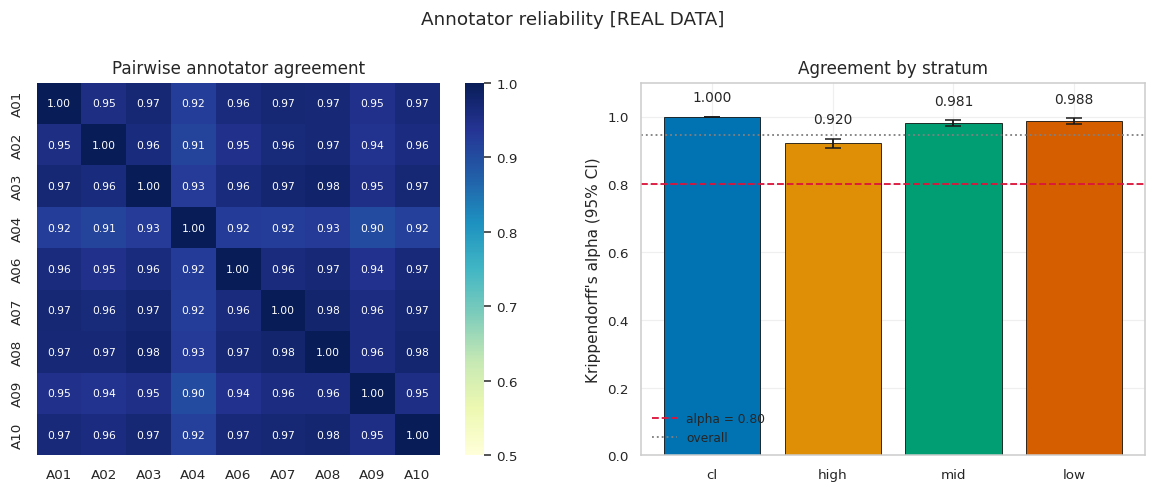

In [14]:
alpha_all = alpha_with_ci(annot, seed=CFG.stats_seed)
alpha_by = {s: alpha_with_ci(annot[annot["stratum"] == s], seed=CFG.stats_seed)
            for s in STRATA}
print(f"Krippendorff's alpha, all items: {fmt_ci(*alpha_all)}")
for s, v in alpha_by.items():
    print(f"  {s:<5}: {fmt_ci(*v)}")

piv = annot.pivot_table(index="item_uid", columns="annotator_id",
                        values="response", aggfunc="first").reindex(columns=ANN_IDS)

def agreement_matrix(R):
    """R: items x annotators array of int codes, -1 = missing."""
    A = R.shape[1]
    out = np.eye(A)
    for i, j in combinations(range(A), 2):
        m = (R[:, i] >= 0) & (R[:, j] >= 0)
        out[i, j] = out[j, i] = np.mean(R[m, i] == R[m, j]) if m.any() else np.nan
    return out

code_map = {c: i for i, c in enumerate(RESP_CATS)}
R_codes = piv.apply(lambda col: col.map(code_map)).fillna(-1).astype(int).to_numpy()
agree = pd.DataFrame(agreement_matrix(R_codes), index=ANN_IDS, columns=ANN_IDS)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
sns.heatmap(agree, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0.5, vmax=1.0,
            ax=axes[0], annot_kws={"fontsize": 7})
axes[0].set_title("Pairwise annotator agreement")
pts = [alpha_by[s][0] for s in STRATA]
err = np.array([[alpha_by[s][0] - alpha_by[s][1] for s in STRATA],
                [alpha_by[s][2] - alpha_by[s][0] for s in STRATA]])
bars = axes[1].bar(STRATA, pts, yerr=err, capsize=5, color=PALETTE[:len(STRATA)],
                   edgecolor="black", linewidth=0.5)
axes[1].bar_label(bars, fmt="%.3f", fontsize=9, padding=8)
axes[1].axhline(0.80, ls="--", color="crimson", lw=1.2, label="alpha = 0.80")
axes[1].axhline(alpha_all[0], ls=":", color="grey", lw=1.2, label="overall")
axes[1].set_ylim(0, 1.1); axes[1].set_ylabel("Krippendorff's alpha (95% CI)")
axes[1].set_title("Agreement by stratum"); axes[1].legend(fontsize=8)
fig.suptitle(f"Annotator reliability [{MODE}]", y=1.03, fontsize=12)
savefig(fig, "sfig03_reliability")
plt.show()

## 6. Soft Labels, Item Taxonomy, and Annotator-Noise Correction

For each item, the human distribution $q_i$ is the vote share over the ten digits. Illegible and not-a-digit responses are reported as separate rates rather than folded into $q_i$.

**Primary taxonomy (pre-registered).** Rules are applied in this order:

| Category | Rule |
| --- | --- |
| `insufficient` | fewer than `min_digit_votes` digit votes |
| `illegible` | illegible rate ≥ `illegible_threshold` |
| `suspected_mislabel` | human mode ≠ Ekush label and mode share ≥ `mislabel_threshold` |
| `unambiguous` | at most `unambiguous_max_dissent` digit votes differ from the mode |
| `ambiguous` | everything else |

Allowing one dissent means a single careless click cannot turn an easy image into an "ambiguous" one.

**Noise correction (sensitivity analysis).** Some disagreement is simply annotator error. Each retained annotator's error rate $e_a$ is measured where images are clear: on the easy `low` stratum, against the Ekush label, with a Jeffreys prior. Two quantities follow:

- **Noise-consistency test.** For each item, compute $P(D \ge d)$, where $D$ is a Poisson-binomial count of errors among the annotators who voted and $d$ is the observed number of votes against the mode. If $P \ge$ `noise_test_alpha`, the disagreement is consistent with annotator error alone and the item is "unambiguous" under this rule. Dissent against the mode can never exceed errors against the true digit, so this rule gives a **lower bound** on genuine ambiguity. The vote rule, and the stricter unanimity rule, give upper bounds.
- **Reliability-weighted posterior.** A one-coin noise model with uniform prior gives each digit's posterior probability, so more reliable annotators count for more.

An earlier draft used unsupervised Dawid–Skene. It was dropped: when images are genuinely ambiguous, a single-truth model blames the annotators, and in testing it estimated about 50% annotator accuracy and "explained away" most real disagreement.

**A note on what the Ekush label means.** In form-based collections such as Ekush, the stored label records the digit the writer was *asked* to write. A "suspected mislabel" is therefore an image whose written form most readers take for a different digit. That can mean a writing slip, a scanning or cropping artifact, or a genuine labelling error; the analysis cannot tell these apart.

In [15]:
def summarise_votes(df):
    rows = []
    for uid, g in df.groupby("item_uid"):
        resp = g["response"]
        counts = np.array([int((resp == c).sum()) for c in DIGIT_CLASSES])
        n_dig = int(counts.sum())
        if n_dig:
            q = counts / n_dig
            mx = counts.max()
            tied = np.flatnonzero(counts == mx)
            mode = int(tied[0])
        else:
            q, mx, tied, mode = np.full(10, np.nan), 0, np.array([], int), -1
        ek = UID_TO_LABEL[uid]
        rows.append({
            "item_uid": uid, "n_annotators": len(resp),
            "n_illegible": int((resp == "illegible").sum()),
            "n_not_digit": int((resp == "not_digit").sum()),
            "n_digit_votes": n_dig,
            "illegible_rate": float((resp == "illegible").mean()),
            "guess_rate": float((g["confidence"] == "guess").mean()),
            **{f"votes_{c}": counts[i] for i, c in enumerate(DIGIT_CLASSES)},
            **{f"q_{c}": q[i] for i, c in enumerate(DIGIT_CLASSES)},
            "human_mode": mode, "mode_tied": len(tied) > 1,
            "n_dissent": n_dig - int(mx),
            "human_max_share": float(mx / n_dig) if n_dig else np.nan,
            "human_entropy": float(entropy(q)) if n_dig else np.nan,
            # tie-aware support for the Ekush label under consensus
            "consensus_supports_ekush": (1.0 / len(tied) if ek in tied else 0.0)
                                         if n_dig else np.nan,
        })
    return pd.DataFrame(rows)


def poisson_binomial_tail(ps, d):
    """P(sum of independent Bernoulli(ps) >= d)."""
    dist = np.array([1.0])
    for p in ps:
        dist = np.convolve(dist, [1 - p, p])
    return float(dist[d:].sum()) if d < len(dist) else 0.0


soft = summarise_votes(annot)
soft["stratum"] = soft["item_uid"].map(UID_TO_STRATUM)
soft["ekush_label"] = soft["item_uid"].map(UID_TO_LABEL)
soft["item_index"] = soft["item_uid"].map(UID_TO_INDEX)
soft = soft.merge(items[["item_uid", "filepath", "ensemble_pred", "ensemble_conf",
                         "predictive_entropy", "aleatoric_entropy"]],
                  on="item_uid", how="left")

# Annotator error rates, measured on the easy stratum. Low-stratum items where a
# clear majority contradicts Ekush are left out, so label errors are not
# charged to the annotators.
clear_low = set(soft.loc[(soft["stratum"] == "low") &
                         ~((soft["human_mode"] != soft["ekush_label"]) &
                           (soft["human_max_share"] >= CFG.mislabel_threshold)), "item_uid"])
ctrl_votes = annot[annot["item_uid"].isin(clear_low) & annot["response"].isin(DIGIT_CLASSES)]
err_rows = {}
for aid in ANN_IDS:
    g = ctrl_votes[ctrl_votes["annotator_id"] == aid]
    wrong = int((g["response"].astype(int) != g["item_uid"].map(UID_TO_LABEL)).sum())
    err_rows[aid] = (wrong + 0.5) / (len(g) + 1.0)          # Jeffreys prior
NOISE_ERR = pd.Series(err_rows)
NOISE_ACC = 1.0 - NOISE_ERR
reliability.loc[ANN_IDS, "noise_model_accuracy"] = NOISE_ACC.round(4)

vote_piv = (annot.pivot_table(index="item_uid", columns="annotator_id", values="response",
                              aggfunc="first").reindex(index=soft["item_uid"], columns=ANN_IDS))
noise_p, WMV = [], np.zeros((len(soft), 10))
for r_i, (uid, row) in enumerate(vote_piv.iterrows()):
    votes = {a: int(v) for a, v in row.items() if isinstance(v, str) and v in DIGIT_CLASSES}
    logp = np.zeros(10)
    for a, v in votes.items():
        lw = np.full(10, np.log(NOISE_ERR[a] / 9)); lw[v] = np.log(NOISE_ACC[a])
        logp += lw
    logp -= logp.max()
    WMV[r_i] = np.exp(logp) / np.exp(logp).sum()
    d = int(soft.loc[r_i, "n_dissent"])
    noise_p.append(poisson_binomial_tail([NOISE_ERR[a] for a in votes], d) if votes else np.nan)
soft["noise_p"] = noise_p
soft["wmv_max"] = WMV.max(1)
for c in range(10):
    soft[f"wmv_{c}"] = WMV[:, c]


def categorise(r, rule="primary"):
    if r["n_digit_votes"] < CFG.min_digit_votes:
        return "insufficient"
    if r["illegible_rate"] >= CFG.illegible_threshold:
        return "illegible"
    if r["human_mode"] != r["ekush_label"] and r["human_max_share"] >= CFG.mislabel_threshold:
        return "suspected_mislabel"
    if rule == "primary":
        clear = r["n_dissent"] <= CFG.unambiguous_max_dissent
    elif rule == "unanimous":
        clear = r["n_dissent"] == 0
    else:  # noise-consistency test
        clear = r["noise_p"] >= CFG.noise_test_alpha
    return "unambiguous" if clear else "ambiguous"

soft["category"] = soft.apply(categorise, axis=1)
soft["category_unanimous"] = soft.apply(lambda r: categorise(r, "unanimous"), axis=1)
soft["category_noise"] = soft.apply(lambda r: categorise(r, "noise"), axis=1)
soft["noise_explained"] = (soft["category"] == "ambiguous") & (soft["category_noise"] == "unambiguous")
LEGIBLE = soft["category"].isin(["ambiguous", "unambiguous", "suspected_mislabel"])

CAT_ORDER = ["unambiguous", "ambiguous", "suspected_mislabel", "illegible", "insufficient"]
tax = (soft.groupby(["stratum", "category"]).size().unstack(fill_value=0)
       .reindex(index=STRATA, columns=CAT_ORDER, fill_value=0))
tax["total"] = tax.sum(axis=1)
print(f"[{MODE}]  Primary item taxonomy by stratum\n")
print(tax.to_string())
tax.to_csv(Path(CFG.tables_dir) / "table_item_taxonomy.csv")

def strat_share(mask):
    """Corpus-level share of a boolean item property (stratified estimate)."""
    return sum(STRATUM_WEIGHT[s] * mask[soft["stratum"] == s].mean() for s in STRATA)

sens = pd.DataFrame({
    rule: {"ambiguous (annotated)": int((soft[col] == "ambiguous").sum()),
           "unambiguous (annotated)": int((soft[col] == "unambiguous").sum()),
           "ambiguous, corpus share (%)": 100 * strat_share(soft[col] == "ambiguous")}
    for rule, col in [("Primary (<= 1 dissent)", "category"),
                      ("Unanimity (upper bound)", "category_unanimous"),
                      ("Noise-consistency (lower bound)", "category_noise")]}).T.round(3)
print(f"\nTaxonomy sensitivity to the ambiguity rule\n")
print(sens.to_string())
print(f"\nAmbiguous by votes but consistent with annotator noise: "
      f"{int(soft['noise_explained'].sum())} items")
sens.to_csv(Path(CFG.tables_dir) / "table_taxonomy_sensitivity.csv")
print("\nAnnotator accuracy on clear control items (noise model):")
print(NOISE_ACC.round(4).to_string())

[REAL DATA]  Primary item taxonomy by stratum

category  unambiguous  ambiguous  suspected_mislabel  illegible  insufficient  total
stratum                                                                             
cl                  0          0                   2          0             0      2
high              575         20                   2          0             3    600
mid               200          0                   0          0             0    200
low               200          0                   0          0             0    200

Taxonomy sensitivity to the ambiguity rule

                                 ambiguous (annotated)  unambiguous (annotated)  ambiguous, corpus share (%)
Primary (<= 1 dissent)                            20.0                    975.0                        0.661
Unanimity (upper bound)                           62.0                    933.0                        3.384
Noise-consistency (lower bound)                   62.0                 

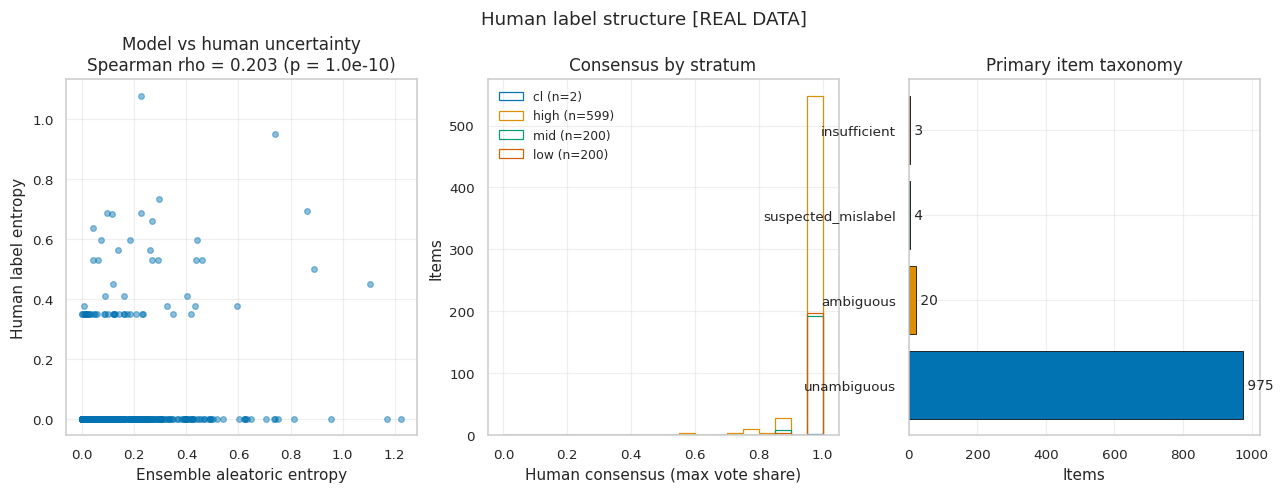

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
ok = soft[LEGIBLE][["aleatoric_entropy", "human_entropy"]].dropna()
axes[0].scatter(ok["aleatoric_entropy"], ok["human_entropy"], s=14, alpha=0.45,
                color=PALETTE[0])
if len(ok) > 2:
    rho_mh, p_mh = stats.spearmanr(ok["aleatoric_entropy"], ok["human_entropy"])
    axes[0].set_title(f"Model vs human uncertainty\nSpearman rho = {rho_mh:.3f} "
                      f"(p = {p_mh:.1e})")
else:
    rho_mh, p_mh = np.nan, np.nan
axes[0].set_xlabel("Ensemble aleatoric entropy")
axes[0].set_ylabel("Human label entropy")

for i, s in enumerate(STRATA):
    sub = soft[soft["stratum"] == s]["human_max_share"].dropna()
    axes[1].hist(sub, bins=np.linspace(0, 1, 21), histtype="step", lw=1.8,
                 color=PALETTE[i], label=f"{s} (n={len(sub)})")
axes[1].set_xlabel("Human consensus (max vote share)")
axes[1].set_ylabel("Items"); axes[1].set_title("Consensus by stratum")
axes[1].legend(fontsize=8)

cat_counts = soft["category"].value_counts().reindex(CAT_ORDER).dropna()
axes[2].barh(cat_counts.index, cat_counts.values,
             color=PALETTE[:len(cat_counts)], edgecolor="black", linewidth=0.5)
for i, v in enumerate(cat_counts.values):
    axes[2].text(v, i, f" {int(v)}", va="center", fontsize=9)
axes[2].set_xlabel("Items"); axes[2].set_title("Primary item taxonomy")
fig.suptitle(f"Human label structure [{MODE}]", y=1.03, fontsize=12)
savefig(fig, "sfig04_soft_label_structure")
plt.show()

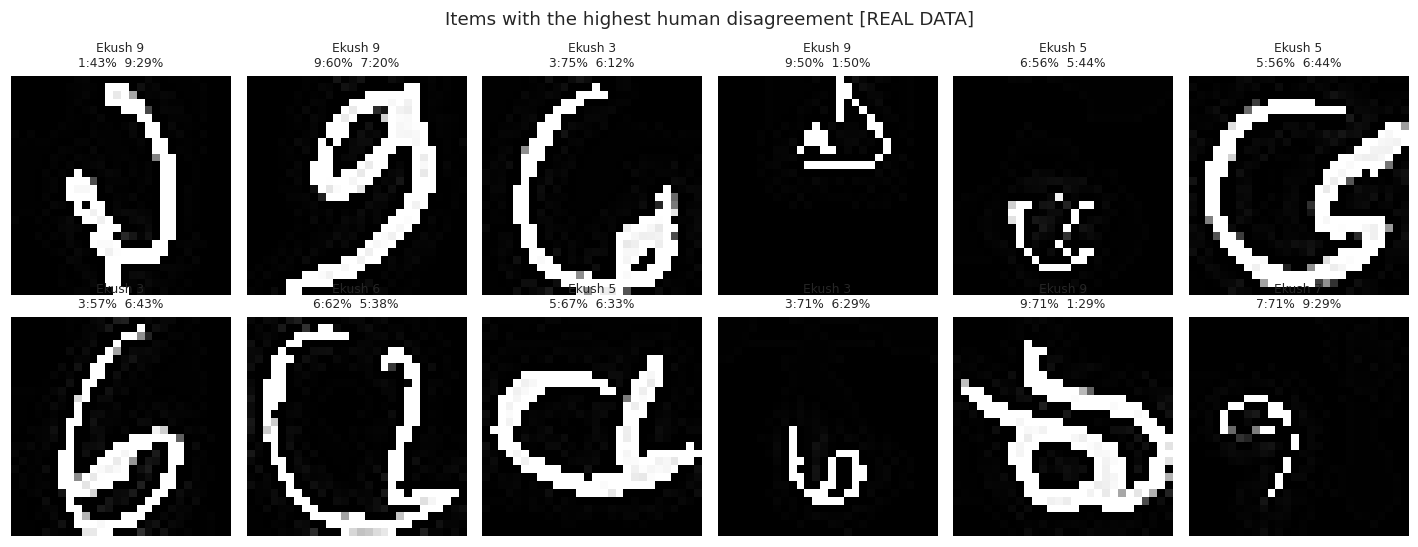

Suspected label errors: 4


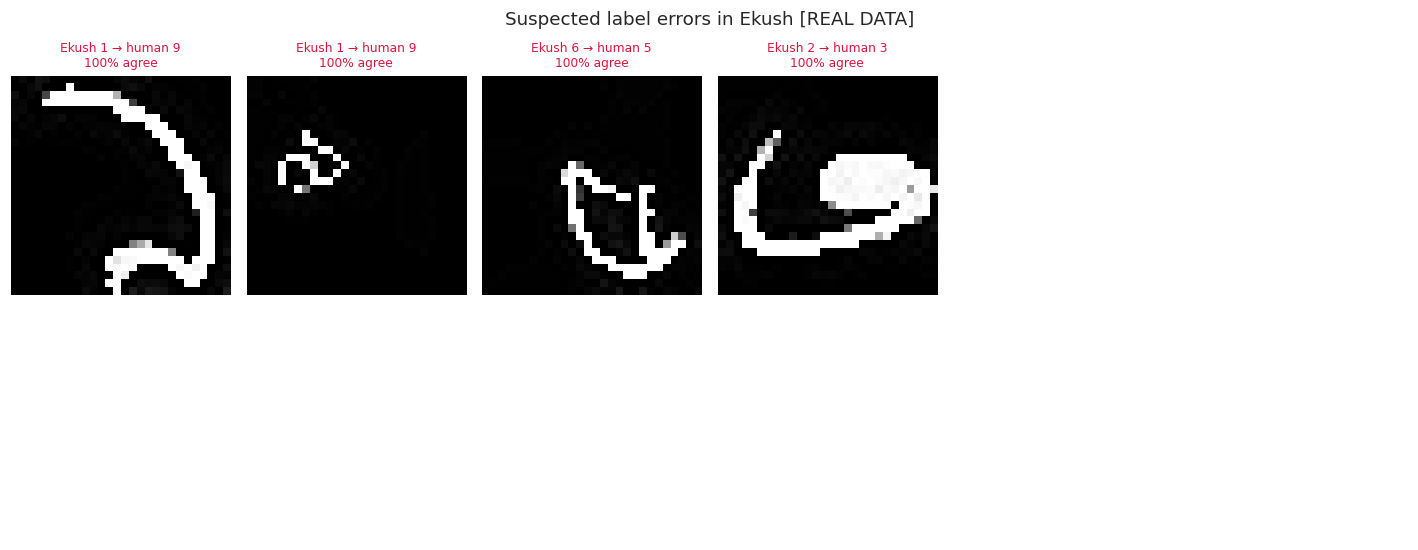

In [17]:
amb = soft[soft["category"] == "ambiguous"].nlargest(12, "human_entropy")
if len(amb):
    fig, axes = plt.subplots(2, 6, figsize=(13, 5))
    for ax, (_, r) in zip(axes.ravel(), amb.iterrows()):
        ax.imshow(Image.open(r["filepath"]).convert("L"), cmap="gray")
        ax.axis("off")
        top = np.argsort([r[f"q_{c}"] for c in DIGIT_CLASSES])[::-1][:2]
        ax.set_title(f"Ekush {r['ekush_label']}\n"
                     f"{top[0]}:{r[f'q_{top[0]}']:.0%}  {top[1]}:{r[f'q_{top[1]}']:.0%}",
                     fontsize=8)
    for ax in axes.ravel()[len(amb):]:
        ax.axis("off")
    fig.suptitle(f"Items with the highest human disagreement [{MODE}]", y=0.99, fontsize=12)
    fig.tight_layout(); savefig(fig, "sfig05_ambiguous_gallery")
    plt.show()

mis = soft[soft["category"] == "suspected_mislabel"].sort_values(
    "human_max_share", ascending=False)
mis[["item_uid", "filepath", "stratum", "ekush_label", "human_mode",
     "human_max_share", "noise_p"]].assign(filepath=lambda d: d["filepath"].map(rel_key)) \
   .to_csv(Path(CFG.tables_dir) / "table_suspected_mislabels.csv", index=False)
print(f"Suspected label errors: {len(mis)}")
if len(mis):
    n = min(12, len(mis))
    fig, axes = plt.subplots(2, 6, figsize=(13, 5))
    for ax, (_, r) in zip(axes.ravel(), mis.head(n).iterrows()):
        ax.imshow(Image.open(r["filepath"]).convert("L"), cmap="gray")
        ax.axis("off")
        ax.set_title(f"Ekush {r['ekush_label']} → human {r['human_mode']}\n"
                     f"{r['human_max_share']:.0%} agree", fontsize=8, color="crimson")
    for ax in axes.ravel()[n:]:
        ax.axis("off")
    fig.suptitle(f"Suspected label errors in Ekush [{MODE}]", y=0.99, fontsize=12)
    fig.tight_layout(); savefig(fig, "sfig06_suspected_mislabels")
    plt.show()

## 7. Headline Results

### 7.1 How much of the Ekush test set does human consensus support?

Three corpus-level estimands are reported. Each uses the stratified estimator with a within-stratum bootstrap, over legible items.

| Estimand | Definition | Interpretation |
| --- | --- | --- |
| **A_cons** (primary) | P(panel majority reads the Ekush label); ties count fractionally | Directly comparable to benchmark accuracy: a classifier that reads like the panel scores about this against Ekush |
| **A_wmv** | mean reliability-weighted posterior of the Ekush label | A_cons with each vote weighted by annotator accuracy |
| **C_annot** | E[max_c q(c)] | Best achievable agreement with a *single random annotator*; includes annotator noise, so it is always lower |

If a model's full-test accuracy is significantly **above** A_cons, it matches the Ekush labels on images where human readers do not. That is evidence it has learned dataset-specific regularities, not a better reading of the handwriting.

If A_cons is close to 1, the benchmark's labels are well supported. That is a positive result and should be reported as plainly as a negative one.

In [18]:
def strat_bootstrap(values, strata, B=None, seed=None):
    """Stratified (Horvitz-Thompson) mean with within-stratum bootstrap CI."""
    B = B or CFG.n_bootstrap
    rs = np.random.RandomState(CFG.stats_seed if seed is None else seed)
    values, strata = np.asarray(values, float), np.asarray(strata)
    present = [s for s in STRATA if np.any((strata == s) & ~np.isnan(values))]
    wsum = sum(STRATUM_WEIGHT[s] for s in present)
    point, boot = 0.0, np.zeros(B)
    for s in present:
        v = values[(strata == s) & ~np.isnan(values)]
        w = STRATUM_WEIGHT[s] / wsum
        point += w * v.mean()
        boot += w * v[rs.randint(0, len(v), (B, len(v)))].mean(1)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return float(point), float(lo), float(hi)


leg = soft[LEGIBLE].reset_index(drop=True)
leg["wmv_ekush"] = WMV[np.flatnonzero(LEGIBLE.to_numpy()), leg["ekush_label"].to_numpy()]
mode_sets = [set(np.flatnonzero(v == v.max()))
             for v in leg[[f"votes_{c}" for c in DIGIT_CLASSES]].to_numpy()]

estimands = {
    "A_cons: consensus supports Ekush label": leg["consensus_supports_ekush"],
    "A_wmv: reliability-weighted support": leg["wmv_ekush"],
    "C_annot: random-annotator ceiling": leg["human_max_share"],
}
ceil_rows = []
for name, vals in estimands.items():
    pt, lo, hi = strat_bootstrap(vals, leg["stratum"])
    row = {"Estimand": name, "Estimate (%)": 100 * pt,
           "95% CI low": 100 * lo, "95% CI high": 100 * hi}
    for s in STRATA:
        row[f"{s} stratum mean (%)"] = 100 * vals[leg["stratum"] == s].mean()
    ceil_rows.append(row)
ceiling_df = pd.DataFrame(ceil_rows).set_index("Estimand").round(3)

illeg_share = strat_share(soft["category"] == "illegible")
print(f"[{MODE}]  Corpus-level human-support estimands "
      f"(stratified, B = {CFG.n_bootstrap}; n legible = {len(leg)})\n")
print(ceiling_df.to_string())
print(f"\nEstimated corpus share of illegible images: {100 * illeg_share:.3f}%")
ceiling_df.to_csv(Path(CFG.tables_dir) / "table_accuracy_ceiling.csv")

A_CONS = ceiling_df.iloc[0][["Estimate (%)", "95% CI low", "95% CI high"]].to_numpy() / 100

print("\nFull test-split accuracy vs A_cons:")
cmp_rows = []
for t in MEMBERS:
    acc, lo, hi = member_test_acc.loc[t, ["Test accuracy", "95% CI low", "95% CI high"]]
    if lo > A_CONS[2]:
        verdict = "ABOVE consensus support (CIs disjoint)"
    elif hi < A_CONS[1]:
        verdict = "below consensus support (CIs disjoint)"
    else:
        verdict = "not distinguishable from consensus support"
    cmp_rows.append({"Model": t, "Test accuracy (%)": 100 * acc, "Verdict": verdict})
    print(f"  {t:<28} {100 * acc:6.2f}%  {verdict}")
for k, v in CFG.literature_accuracies.items():
    print(f"  {k:<28} {100 * v:6.2f}%  (literature, verify citation)")
pd.DataFrame(cmp_rows).to_csv(Path(CFG.tables_dir) / "table_accuracy_vs_ceiling.csv",
                              index=False)

[REAL DATA]  Corpus-level human-support estimands (stratified, B = 5000; n legible = 999)

                                        Estimate (%)  95% CI low  95% CI high  cl stratum mean (%)  high stratum mean (%)  mid stratum mean (%)  low stratum mean (%)
Estimand                                                                                                                                                             
A_cons: consensus supports Ekush label        99.718      99.535       99.867                  0.0                 98.911               100.000               100.000
A_wmv: reliability-weighted support           99.731      99.564       99.867                  0.0                 98.977               100.000               100.000
C_annot: random-annotator ceiling             99.468      99.296       99.630                100.0                 98.288                99.556                99.826

Estimated corpus share of illegible images: 0.000%

Full test-split accuracy v

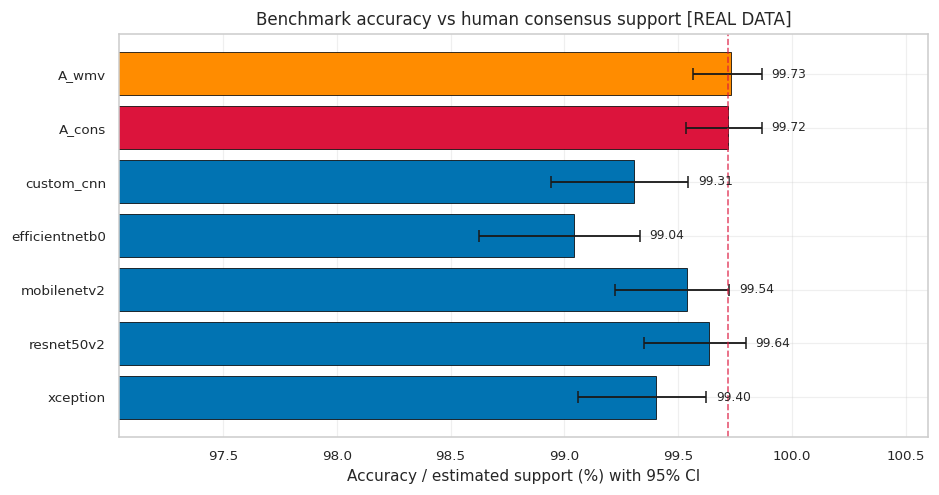

In [19]:
fig, ax = plt.subplots(figsize=(9.5, 0.42 * (len(MEMBERS) + len(CFG.literature_accuracies) + 3) + 1.4))
names, vals, errs, cols = [], [], [], []
for t in MEMBERS:
    a, lo, hi = member_test_acc.loc[t, ["Test accuracy", "95% CI low", "95% CI high"]]
    names.append(t); vals.append(100 * a); errs.append((100 * (a - lo), 100 * (hi - a)))
    cols.append(PALETTE[0])
for k, v in CFG.literature_accuracies.items():
    names.append(f"{k} (lit.)"); vals.append(100 * v); errs.append((0, 0)); cols.append(PALETTE[7])
for est, colr in zip(ceiling_df.index[:2], ["crimson", "darkorange"]):
    pt, lo, hi = ceiling_df.loc[est, ["Estimate (%)", "95% CI low", "95% CI high"]]
    names.append(est.split(":")[0]); vals.append(pt); errs.append((pt - lo, hi - pt))
    cols.append(colr)
y = np.arange(len(names))
ax.barh(y, vals, xerr=np.array(errs).T, color=cols, edgecolor="black",
        linewidth=0.5, capsize=4)
span = 100.6 - max(0, min(vals) - 2)
for yi, v, (_, e_hi) in zip(y, vals, errs):
    ax.text(v + e_hi + 0.012 * span, yi, f"{v:.2f}", va="center", fontsize=8)
ax.set_yticks(y); ax.set_yticklabels(names)
ax.axvline(100 * A_CONS[0], ls="--", color="crimson", lw=1.1, alpha=0.7)
ax.set_xlim(max(0, min(vals) - 2), 100.6)
ax.set_xlabel("Accuracy / estimated support (%) with 95% CI")
ax.set_title(f"Benchmark accuracy vs human consensus support [{MODE}]")
savefig(fig, "sfig07_ceiling")
plt.show()

### 7.2 How precise are Notebook 1's label-issue candidates?

The `cl` stratum is a census of the top-ranked confident-learning candidates on the test set, so human judgement measures the method's **precision** directly. Each candidate falls into one of these groups:

- **Confirmed:** the item is a `suspected_mislabel` (a clear majority reads a different digit).
- **Majority rejects the label:** the panel majority does not read the Ekush label (a looser version of confirmed).
- **Ambiguous:** humans disagree among themselves.
- **Supports the label:** the panel agrees with the Ekush label, so this is a model misreading rather than a label error.

**Recall** is estimated from suspected mislabels found in the other strata, weighted up to the corpus. It uses the stratified estimator with a within-stratum bootstrap.

In [20]:
CLP = None
cl_soft = soft[soft["stratum"] == "cl"]
if len(cl_soft):
    legible_cl = cl_soft[cl_soft["category"].isin(["ambiguous", "unambiguous", "suspected_mislabel"])]
    n_cl = len(legible_cl)
    groups = {
        "Confirmed (suspected_mislabel)": legible_cl["category"] == "suspected_mislabel",
        "Majority rejects Ekush label": legible_cl["consensus_supports_ekush"] < 0.5,
        "Ambiguous": legible_cl["category"] == "ambiguous",
        "Panel supports Ekush label": (legible_cl["category"] == "unambiguous")
                                      & (legible_cl["consensus_supports_ekush"] == 1),
    }
    rows = []
    for name, mask in groups.items():
        k = int(mask.sum()); lo, hi = wilson(k, n_cl)
        rows.append({"Outcome": name, "Items": k, "Share": k / max(n_cl, 1),
                     "95% CI low": lo, "95% CI high": hi})
    clp_tab = pd.DataFrame(rows).set_index("Outcome")

    sugg = dict(zip(cl_candidates_test["position"], cl_candidates_test["suggested_label"]))
    conf = legible_cl[groups["Confirmed (suspected_mislabel)"]]
    agree_sugg = float(np.mean([sugg.get(i, -1) == m for i, m in
                                zip(conf["item_index"], conf["human_mode"])])) if len(conf) else np.nan

    k_conf = int(groups["Confirmed (suspected_mislabel)"].sum())
    others = [s for s in STRATA if s != "cl"]
    rs_ = np.random.RandomState(CFG.stats_seed + 5)
    point_out, boot_out = 0.0, np.zeros(CFG.n_bootstrap)
    for s in others:
        v = (soft.loc[soft["stratum"] == s, "category"] == "suspected_mislabel").to_numpy(float)
        if len(v):
            point_out += STRATUM_POPULATION[s] * v.mean()
            boot_out += STRATUM_POPULATION[s] * v[rs_.randint(0, len(v), (CFG.n_bootstrap, len(v)))].mean(1)
    recall = k_conf / (k_conf + point_out) if (k_conf + point_out) > 0 else np.nan
    boot_rec = k_conf / np.maximum(k_conf + boot_out, 1e-12)
    CLP = {"n_legible": n_cl, "precision_confirmed": clp_tab.iloc[0]["Share"],
           "precision_ci": [clp_tab.iloc[0]["95% CI low"], clp_tab.iloc[0]["95% CI high"]],
           "majority_rejects_share": clp_tab.iloc[1]["Share"],
           "suggested_label_matches_humans": agree_sugg,
           "est_mislabels_outside_candidates": point_out,
           "recall": recall, "recall_ci": list(np.percentile(boot_rec, [2.5, 97.5]))}
    print(f"[{MODE}]  Label-issue candidates judged by the panel (n = {n_cl} legible of {len(cl_soft)})\n")
    print(clp_tab.round(4).to_string())
    print(f"\nAmong confirmed items, CL's suggested label equals the human mode: {agree_sugg:.3f}")
    print(f"Estimated suspected mislabels elsewhere in the test set: {point_out:.1f}")
    print(f"Estimated recall of the candidate list: {fmt_ci(recall, *CLP['recall_ci'])}")
    clp_tab.round(4).to_csv(Path(CFG.tables_dir) / "table_label_issue_precision.csv")
else:
    print("No cl stratum in this package.")

[REAL DATA]  Label-issue candidates judged by the panel (n = 2 legible of 2)

                                Items  Share  95% CI low  95% CI high
Outcome                                                              
Confirmed (suspected_mislabel)      2    1.0      0.3424       1.0000
Majority rejects Ekush label        2    1.0      0.3424       1.0000
Ambiguous                           0    0.0      0.0000       0.6576
Panel supports Ekush label          0    0.0      0.0000       0.6576

Among confirmed items, CL's suggested label equals the human mode: 1.000
Estimated suspected mislabels elsewhere in the test set: 2.0
Estimated recall of the candidate list: 0.5000 [0.2857, 1.0000]


### 7.3 Does the model ranking survive, and is it statistically resolved?

Each member is scored on the annotated legible items under four regimes:

1. All items, against the Ekush label (the conventional protocol).
2. Unambiguous items only, against the Ekush label.
3. All items, against the human mode (a prediction counts as correct if it is among tied modes).
4. Ambiguous items only, against the human mode.

For each regime the analysis reports:

- the accuracy with a stratified bootstrap CI;
- the **bootstrap rank distribution** (mean rank, 95% rank interval, and P(rank = 1));
- **exact McNemar tests** for every pair of models, Holm-corrected within the regime.

A ranking is "resolved" only if the adjacent pairs differ significantly. Point-estimate rank flips between regimes are reported, but they are not evidence on their own.

In [21]:
def boot_index_sets(strata, B, seed):
    rs = np.random.RandomState(seed)
    strata = np.asarray(strata)
    parts = []
    for s in STRATA:
        pos = np.flatnonzero(strata == s)
        if len(pos):
            parts.append(pos[rs.randint(0, len(pos), (B, len(pos)))])
    return np.concatenate(parts, axis=1)

def holm(pvals):
    p = np.asarray(pvals, float)
    order = np.argsort(p)
    adj = np.empty_like(p)
    running = 0.0
    for rank, i in enumerate(order):
        running = max(running, (len(p) - rank) * p[i])
        adj[i] = min(1.0, running)
    return adj

def mcnemar_exact(c1, c2):
    b = int(np.sum(c1 & ~c2)); c = int(np.sum(~c1 & c2))
    if b + c == 0:
        return b, c, 1.0
    return b, c, float(stats.binomtest(min(b, c), b + c, 0.5).pvalue)

idx_leg = leg["item_index"].to_numpy()
cat = leg["category"].to_numpy()
regime_masks = {
    "All (Ekush label)": np.ones(len(leg), bool),
    "Unambiguous (Ekush label)": cat == "unambiguous",
    "All (human mode)": np.ones(len(leg), bool),
    "Ambiguous (human mode)": cat == "ambiguous",
}

def correct_matrix(regime, mask):
    out = []
    for t in MEMBERS:
        pr = member_probs[t][idx_leg[mask]].argmax(1)
        if "Ekush" in regime:
            out.append(pr == leg["ekush_label"].to_numpy()[mask])
        else:
            ms = [mode_sets[i] for i in np.flatnonzero(mask)]
            out.append(np.array([p in s for p, s in zip(pr, ms)]))
    return np.array(out)

rank_rows, pair_rows = [], []
for regime, mask in regime_masks.items():
    if mask.sum() < 10:
        print(f"{regime}: only {mask.sum()} items, skipped")
        continue
    Cm = correct_matrix(regime, mask)
    st = leg["stratum"].to_numpy()[mask]
    bidx = boot_index_sets(st, CFG.n_bootstrap_rank, CFG.stats_seed)
    boot_acc = Cm[:, bidx].mean(-1)                       # (M, B)
    boot_rank = stats.rankdata(-boot_acc, axis=0, method="min")
    point = Cm.mean(1)
    for m, t in enumerate(MEMBERS):
        lo, hi = np.percentile(boot_acc[m], [2.5, 97.5])
        rlo, rhi = np.percentile(boot_rank[m], [2.5, 97.5])
        rank_rows.append({"Regime": regime, "Model": t, "n": int(mask.sum()),
                          "Accuracy": point[m], "CI low": lo, "CI high": hi,
                          "Point rank": int(stats.rankdata(-point, method="min")[m]),
                          "Mean boot rank": boot_rank[m].mean(),
                          "Rank 95% low": int(rlo), "Rank 95% high": int(rhi),
                          "P(rank 1)": np.mean(boot_rank[m] == 1)})
    pairs = list(combinations(range(len(MEMBERS)), 2))
    res = [mcnemar_exact(Cm[i], Cm[j]) for i, j in pairs]
    adj = holm([r[2] for r in res])
    for (i, j), (b, c, p), pa in zip(pairs, res, adj):
        pair_rows.append({"Regime": regime, "Model A": MEMBERS[i], "Model B": MEMBERS[j],
                          "A right, B wrong": b, "B right, A wrong": c,
                          "p (exact McNemar)": p, "p (Holm)": pa,
                          "Significant": pa < CFG.alpha_level})

ranking = pd.DataFrame(rank_rows)
pairwise = pd.DataFrame(pair_rows)
ranking.round(4).to_csv(Path(CFG.tables_dir) / "table_ranking_regimes.csv", index=False)
pairwise.round(5).to_csv(Path(CFG.tables_dir) / "table_pairwise_mcnemar.csv", index=False)

print(f"[{MODE}]  Accuracy and rank uncertainty by regime\n")
show = ranking.assign(Accuracy=lambda d: [fmt_ci(a, l, h, 4) for a, l, h in
                                          zip(d["Accuracy"], d["CI low"], d["CI high"])],
                      Rank=lambda d: [f"{p} ({l}-{h})" for p, l, h in
                                      zip(d["Point rank"], d["Rank 95% low"], d["Rank 95% high"])])
print(show.pivot(index="Model", columns="Regime", values="Accuracy").to_string())
print()
print(show.pivot(index="Model", columns="Regime", values="Rank").to_string())
print()
print(ranking.pivot(index="Model", columns="Regime", values="P(rank 1)").round(3).to_string())

sig = pairwise.groupby("Regime")["Significant"].agg(["sum", "count"])
print("\nSignificant pairwise differences (Holm-corrected):")
print(sig.rename(columns={"sum": "significant", "count": "pairs"}).to_string())

pt_rank = ranking.pivot(index="Model", columns="Regime", values="Point rank")
RANK_CHANGES = int((pt_rank.nunique(axis=1) > 1).sum())
top_resolved = {}
for regime, g in ranking.groupby("Regime"):
    top_resolved[regime] = bool(g["P(rank 1)"].max() >= 0.95)
print(f"\nModels whose point rank changes across regimes: {RANK_CHANGES} of {len(MEMBERS)}")
print("Top model resolved (P(rank 1) >= 0.95):", top_resolved)

[REAL DATA]  Accuracy and rank uncertainty by regime

Regime                All (Ekush label)         All (human mode)   Ambiguous (human mode) Unambiguous (Ekush label)
Model                                                                                                              
custom_cnn      0.9790 [0.9700, 0.9870]  0.9780 [0.9690, 0.9870]  0.6500 [0.4500, 0.8500]   0.9867 [0.9795, 0.9938]
efficientnetb0  0.9710 [0.9610, 0.9800]  0.9690 [0.9580, 0.9780]  0.6500 [0.4500, 0.8500]   0.9764 [0.9662, 0.9846]
mobilenetv2     0.9860 [0.9790, 0.9920]  0.9840 [0.9760, 0.9910]  0.7000 [0.5000, 0.9000]   0.9918 [0.9856, 0.9969]
resnet50v2      0.9890 [0.9830, 0.9940]  0.9870 [0.9800, 0.9930]  0.8000 [0.6000, 0.9500]   0.9928 [0.9867, 0.9979]
xception        0.9820 [0.9740, 0.9890]  0.9820 [0.9740, 0.9900]  0.7000 [0.5000, 0.9000]   0.9887 [0.9815, 0.9949]

Regime         All (Ekush label) All (human mode) Ambiguous (human mode) Unambiguous (Ekush label)
Model                             

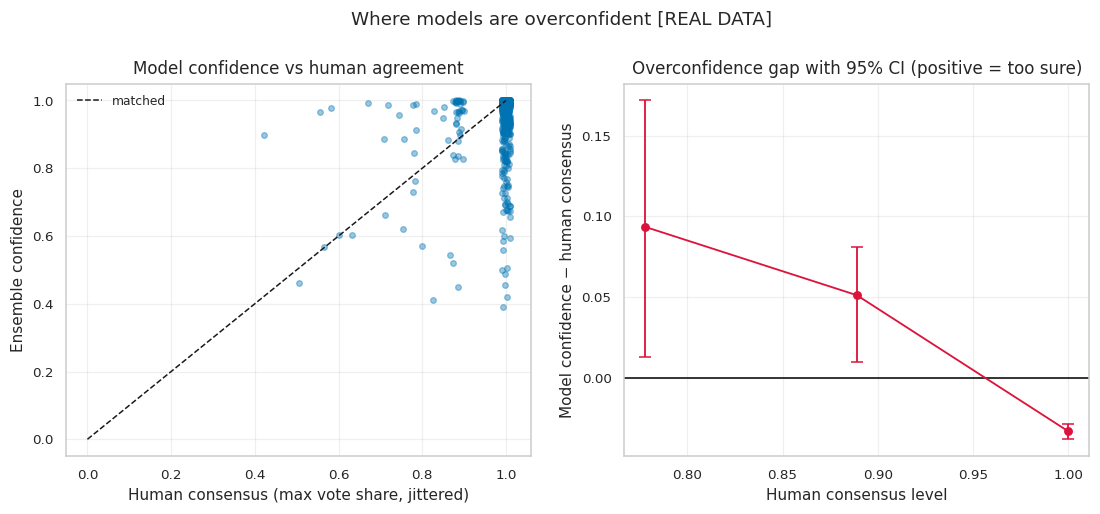

 consensus     gap      lo      hi   n
     0.778  0.0935  0.0128  0.1717   6
     0.889  0.0513  0.0097  0.0808  32
     1.000 -0.0328 -0.0378 -0.0282 937


In [22]:
# Where are models overconfident relative to humans?
Qh = leg[Q_COLS].to_numpy(float)
hshare = leg["human_max_share"].to_numpy()
mconf = p_bar[idx_leg].max(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].scatter(hshare + np.random.RandomState(0).uniform(-0.01, 0.01, len(hshare)),
                mconf, s=14, alpha=0.4, color=PALETTE[0])
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="matched")
axes[0].set_xlabel("Human consensus (max vote share, jittered)")
axes[0].set_ylabel("Ensemble confidence")
axes[0].set_title("Model confidence vs human agreement"); axes[0].legend(fontsize=8)

levels = np.sort(np.unique(np.round(hshare, 3)))
gap_rows = []
for lv in levels:
    m = np.isclose(hshare, lv, atol=1e-3)
    if m.sum() < 5:
        continue
    d = mconf[m] - hshare[m]
    rs = np.random.RandomState(0)
    bs = d[rs.randint(0, len(d), (2000, len(d)))].mean(1)
    gap_rows.append((lv, d.mean(), *np.percentile(bs, [2.5, 97.5]), int(m.sum())))
gap = pd.DataFrame(gap_rows, columns=["consensus", "gap", "lo", "hi", "n"])
axes[1].errorbar(gap["consensus"], gap["gap"], yerr=[gap["gap"] - gap["lo"], gap["hi"] - gap["gap"]],
                 fmt="o-", color="crimson", capsize=4)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_xlabel("Human consensus level")
axes[1].set_ylabel("Model confidence − human consensus")
axes[1].set_title("Overconfidence gap with 95% CI (positive = too sure)")
fig.suptitle(f"Where models are overconfident [{MODE}]", y=1.03, fontsize=12)
savefig(fig, "sfig08_overconfidence")
plt.show()
gap.round(4).to_csv(Path(CFG.tables_dir) / "table_overconfidence_gap.csv", index=False)
print(gap.round(4).to_string(index=False))

## 8. Distributional Metrics

Every metric is computed per item against the human distribution, averaged, and given a stratified bootstrap CI. **P(best)** is the bootstrap probability that a model ranks first on that metric.

| Metric | Penalises | Better |
| --- | --- | --- |
| Jensen–Shannon divergence | Mismatch in the shape of the distribution | lower |
| KL(human ‖ model) | Probability mass missing where humans voted | lower |
| Total variation (= 1 − soft accuracy) | Probability mass on classes humans did not choose | lower |
| Soft Brier | Miscalibration against q | lower |
| Cross-entropy to q | Confident mass on classes humans did not support | lower |
| Confusion-weighted cost | Confusing digits humans never confuse | lower |
| Mode accuracy | Wrong top-1 answer | higher |

Soft accuracy is exactly 1 − TV, so only TV is reported.

The confusion cost's ground metric is **cross-fitted**: it is learned from the human votes on one half of the items and applied to the other half, then the halves are swapped. The released 10×10 cost matrix uses all items.

In [23]:
def _norm(x, axis=-1, eps=1e-12):
    x = np.clip(np.asarray(x, dtype=np.float64), eps, None)
    return x / x.sum(axis=axis, keepdims=True)

def kl_div(p, q):
    p, q = _norm(p), _norm(q)
    return np.sum(p * np.log(p / q), axis=-1)

def js_div(p, q):
    p, q = _norm(p), _norm(q); m = 0.5 * (p + q)
    return 0.5 * kl_div(p, m) + 0.5 * kl_div(q, m)

def total_variation(p, q):
    return 0.5 * np.sum(np.abs(_norm(p) - _norm(q)), axis=-1)

def soft_brier(p, q):
    return np.sum((_norm(p) - _norm(q)) ** 2, axis=-1)

def cross_entropy_to(q_human, p_model):
    return -np.sum(_norm(q_human) * np.log(_norm(p_model)), axis=-1)

def ece(y_true, probs, n_bins=10):
    conf, pred = probs.max(1), probs.argmax(1)
    correct = (pred == y_true).astype(float)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    e = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum():
            e += (m.sum() / len(y_true)) * abs(correct[m].mean() - conf[m].mean())
    return float(e)

def confusion_cost_matrix(Q, floor=0.02):
    Qn = _norm(Q)
    co = Qn.T @ Qn
    np.fill_diagonal(co, 0.0)
    co = co / max(co.max(), 1e-12)
    D = np.clip(1.0 - co, floor, 1.0)
    np.fill_diagonal(D, 0.0)
    return D

def confusion_weighted_cost(q_human, p_model, D):
    return np.einsum("ic,ck,ik->i", _norm(q_human), D, _norm(p_model))

D_COST = confusion_cost_matrix(Qh)
fold = np.random.RandomState(CFG.stats_seed).permutation(len(leg)) % 2
D_FOLD = {f: confusion_cost_matrix(Qh[fold != f]) for f in (0, 1)}

LOWER_BETTER = ["JSD", "KL(human||model)", "Total variation", "Soft Brier",
                "Cross-entropy", "Confusion cost"]
METRICS = LOWER_BETTER + ["Mode accuracy"]

def item_metrics(Pm):
    cost = np.empty(len(leg))
    for f in (0, 1):
        m = fold == f
        cost[m] = confusion_weighted_cost(Qh[m], Pm[m], D_FOLD[f])
    ms = [mode_sets[i] for i in range(len(leg))]
    return {"JSD": js_div(Qh, Pm), "KL(human||model)": kl_div(Qh, Pm),
            "Total variation": total_variation(Qh, Pm), "Soft Brier": soft_brier(Qh, Pm),
            "Cross-entropy": cross_entropy_to(Qh, Pm), "Confusion cost": cost,
            "Mode accuracy": np.array([p in s for p, s in zip(Pm.argmax(1), ms)], float)}

MODELS_PLUS = MEMBERS + ["ENSEMBLE MEAN"]
per_item = {t: item_metrics(p_bar[idx_leg] if t == "ENSEMBLE MEAN"
                            else member_probs[t][idx_leg]) for t in MODELS_PLUS}

bidx = boot_index_sets(leg["stratum"].to_numpy(), CFG.n_bootstrap_rank, CFG.stats_seed + 1)
sm_rows, pbest = [], {}
for metric in METRICS:
    arr = np.array([per_item[t][metric] for t in MODELS_PLUS])
    bm = arr[:, bidx].mean(-1)
    best = bm.argmin(0) if metric in LOWER_BETTER else bm.argmax(0)
    pbest[metric] = np.bincount(best, minlength=len(MODELS_PLUS)) / bm.shape[1]
    for k, t in enumerate(MODELS_PLUS):
        lo, hi = np.percentile(bm[k], [2.5, 97.5])
        sm_rows.append({"Model": t, "Metric": metric, "Mean": arr[k].mean(),
                        "CI low": lo, "CI high": hi, "P(best)": pbest[metric][k]})
softmetrics_long = pd.DataFrame(sm_rows)
softmetrics = softmetrics_long.pivot(index="Model", columns="Metric", values="Mean")[METRICS]
softmetrics_ci = softmetrics_long.assign(
    cell=lambda d: [fmt_ci(m, l, h, 4) for m, l, h in zip(d["Mean"], d["CI low"], d["CI high"])]
).pivot(index="Model", columns="Metric", values="cell")[METRICS]

ranks = pd.DataFrame({m: softmetrics[m].rank(ascending=(m in LOWER_BETTER), method="min")
                      for m in METRICS}).astype(int)
METRIC_RANK_CHANGES = int((ranks.nunique(axis=1) > 1).sum())
KENDALL_W = None
if len(MODELS_PLUS) > 2:
    Rk = ranks.to_numpy().T                        # metrics x models
    m_, n_ = Rk.shape
    S = ((Rk.sum(0) - m_ * (n_ + 1) / 2) ** 2).sum()
    KENDALL_W = float(12 * S / (m_ ** 2 * (n_ ** 3 - n_)))

print(f"[{MODE}]  Distributional metrics (n = {len(leg)} legible items), mean [95% CI]\n")
print(softmetrics_ci.to_string())
print("\nP(best) by metric:")
print(softmetrics_long.pivot(index="Model", columns="Metric", values="P(best)")[METRICS]
      .round(3).to_string())
print(f"\nModels whose rank depends on the metric: {METRIC_RANK_CHANGES} of {len(MODELS_PLUS)}")
print(f"Kendall's W (agreement of metric rankings, 1 = identical): {KENDALL_W:.3f}")
softmetrics_long.round(5).to_csv(Path(CFG.tables_dir) / "table_soft_metrics_long.csv", index=False)
softmetrics_ci.to_csv(Path(CFG.tables_dir) / "table_soft_metrics.csv")

[REAL DATA]  Distributional metrics (n = 999 legible items), mean [95% CI]

Metric                              JSD         KL(human||model)          Total variation               Soft Brier            Cross-entropy           Confusion cost            Mode accuracy
Model                                                                                                                                                                                        
ENSEMBLE MEAN   0.0167 [0.0144, 0.0194]  0.0705 [0.0586, 0.0842]  0.0440 [0.0385, 0.0500]  0.0204 [0.0152, 0.0265]  0.0988 [0.0815, 0.1171]  0.0301 [0.0255, 0.0350]  0.9880 [0.9810, 0.9940]
custom_cnn      0.0226 [0.0191, 0.0263]  0.0993 [0.0805, 0.1198]  0.0558 [0.0484, 0.0636]  0.0339 [0.0253, 0.0431]  0.1276 [0.1045, 0.1518]  0.0387 [0.0328, 0.0453]  0.9780 [0.9690, 0.9870]
efficientnetb0  0.0247 [0.0205, 0.0293]  0.1285 [0.1022, 0.1587]  0.0574 [0.0491, 0.0666]  0.0431 [0.0326, 0.0549]  0.1568 [0.1254, 0.1906]  0.0364 [0.0301, 0.0432]

Cheapest digit confusions under the learned ground cost (all items):
  ৫ (5) <-> ৬ (6)   cost 0.020
  ১ (1) <-> ৯ (9)   cost 0.352
  ৩ (3) <-> ৬ (6)   cost 0.513
  ৭ (7) <-> ৯ (9)   cost 0.574
  ৪ (4) <-> ৫ (5)   cost 0.691
  ১ (1) <-> ২ (2)   cost 0.800
  ৬ (6) <-> ৮ (8)   cost 0.806
  ০ (0) <-> ৩ (3)   cost 0.832


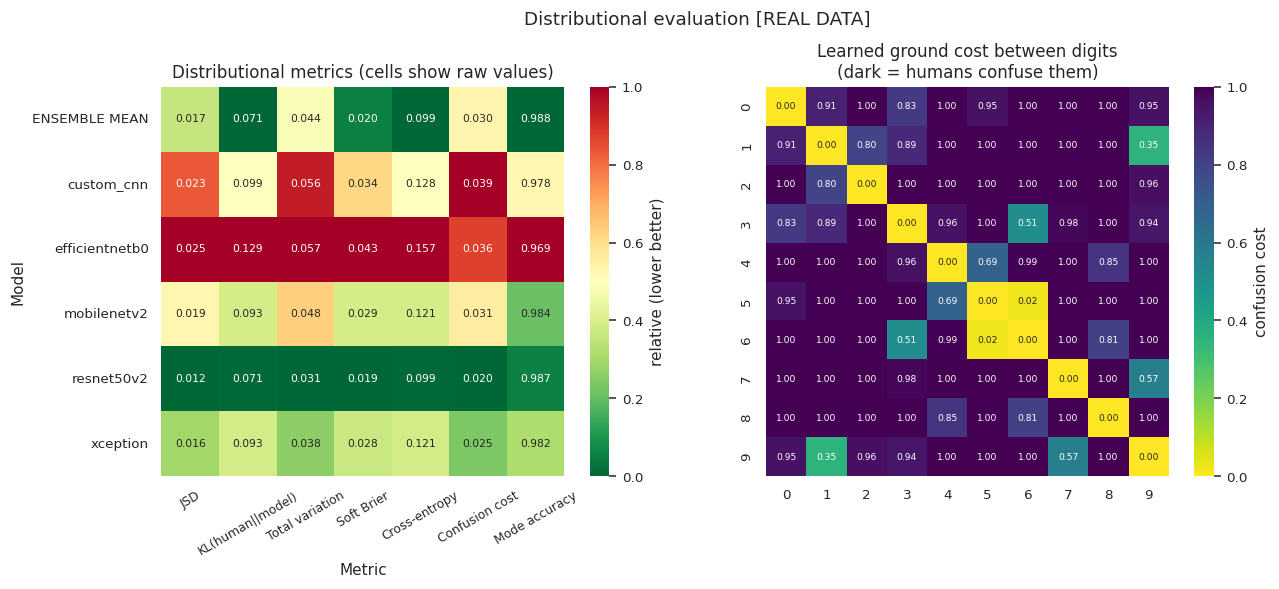

In [24]:
print("Cheapest digit confusions under the learned ground cost (all items):")
pairs_ = [(i, j, D_COST[i, j]) for i in range(10) for j in range(i + 1, 10)]
for i, j, d in sorted(pairs_, key=lambda t: t[2])[:8]:
    print(f"  {DISPLAY_NAMES[i]} <-> {DISPLAY_NAMES[j]}   cost {d:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
nv = softmetrics.copy()
for c in nv.columns:
    v = nv[c]; nv[c] = (v - v.min()) / (v.max() - v.min() + 1e-12)
    if c not in LOWER_BETTER:
        nv[c] = 1 - nv[c]
sns.heatmap(nv, annot=softmetrics.values, fmt=".3f", cmap="RdYlGn_r", ax=axes[0],
            annot_kws={"fontsize": 7}, cbar_kws={"label": "relative (lower better)"})
axes[0].set_title("Distributional metrics (cells show raw values)")
axes[0].tick_params(axis="x", rotation=30, labelsize=8)
sns.heatmap(D_COST, annot=True, fmt=".2f", cmap="viridis_r", xticklabels=range(10),
            yticklabels=range(10), ax=axes[1], annot_kws={"fontsize": 6},
            cbar_kws={"label": "confusion cost"})
axes[1].set_title("Learned ground cost between digits\n(dark = humans confuse them)")
fig.suptitle(f"Distributional evaluation [{MODE}]", y=1.03, fontsize=12)
savefig(fig, "sfig09_soft_metrics")
plt.show()

## 9. Perspectivist Evaluation

Soft labels treat the panel as one population. The perspectivist view asks whether disagreement is *structured*: do subgroups of annotators read certain letterforms consistently differently?

1. **Per-annotator predictability.** How well does each model predict each annotator's own label? The panel baseline is the **leave-one-out** consensus. v1 included the annotator in their own consensus, which inflated that baseline.
2. **Structure tests.** Annotators are clustered on their pairwise agreement, and the cluster separation is compared against two null distributions:
   - **Exchangeable null.** Responses are permuted among annotators within each item. This keeps each item's vote distribution fixed. A rejection means annotators are *not interchangeable*, which differences in skill alone can cause.
   - **Skill-aware parametric test (primary).** The statistic is the residual of the agreement matrix after a rank-1 fit. Differences in skill alone produce a rank-1 pattern, and shared conventions add block structure that the fit cannot absorb. Null panels are simulated so that each annotator reads the item's shared distribution with their own measured reliability, and otherwise answers at random. The shared distribution is estimated by removing the panel's average noise from the observed votes. A rejection here means there is structure **beyond** skill differences and item difficulty. Only this counts as evidence of distinct reading conventions.

   The calibration cell below measures the primary test's size and power on synthetic panels matched to this study (same number of annotators and items, with reliabilities in the observed range). Report that table next to the test result. During development, the rank-1 statistic held its nominal size, and it detected moderate shared conventions far more often than a cluster-separation statistic, which is why it is the primary statistic.
3. **Skill confound, descriptively.** A Mantel correlation between agreement distance and skill difference is reported. With about 10 annotators it has little power and is not used as a decision rule.

In [25]:
soft_uids = soft["item_uid"].tolist()
R_full = (annot.pivot_table(index="item_uid", columns="annotator_id", values="response",
                            aggfunc="first")
          .reindex(index=soft_uids, columns=ANN_IDS)
          .apply(lambda col: col.map(code_map)).fillna(-1).astype(int).to_numpy())
leg_rows = np.flatnonzero(LEGIBLE.to_numpy())

persp_rows = []
for a_i, aid in enumerate(ANN_IDS):
    r = R_full[leg_rows, a_i]
    ok_ = (r >= 0) & (r < 10)
    rows_ = leg_rows[ok_]
    truth = r[ok_]
    others = np.delete(R_full[rows_], a_i, axis=1)
    loo = np.array([np.bincount(o[(o >= 0) & (o < 10)], minlength=10) for o in others])
    has = loo.sum(1) > 0
    rec = {"Annotator": aid, "n": int(ok_.sum()),
           "Control accuracy": float(NOISE_ACC[aid])}
    rs = np.random.RandomState(a_i)
    bi = rs.randint(0, len(truth), (1000, len(truth)))
    for t in MODELS_PLUS:
        Pm = p_bar[soft["item_index"].to_numpy()[rows_]] if t == "ENSEMBLE MEAN" \
            else member_probs[t][soft["item_index"].to_numpy()[rows_]]
        c = (Pm.argmax(1) == truth).astype(float)
        rec[t] = c.mean()
    c = (loo.argmax(1) == truth)[has].astype(float)
    rec["LOO panel consensus"] = c.mean()
    persp_rows.append(rec)

perspectivist = pd.DataFrame(persp_rows).set_index("Annotator")
print(f"[{MODE}]  Predicting each annotator's own label (legible items)\n")
print(perspectivist.round(4).to_string())
mean_model = perspectivist[MEMBERS].mean(axis=1)
PERSP_SPREAD = float(mean_model.max() - mean_model.min())
rho_skill, p_skill = stats.spearmanr(perspectivist["Control accuracy"], mean_model)
print(f"\nSpread of mean model accuracy across annotators: {PERSP_SPREAD:.4f}")
print(f"Correlation with annotator skill (control accuracy): rho = {rho_skill:.3f} (p = {p_skill:.3f})")
print("A strong correlation means models simply agree more with more accurate")
print("annotators -- not evidence of distinct readings.")
perspectivist.round(4).to_csv(Path(CFG.tables_dir) / "table_perspectivist.csv")

[REAL DATA]  Predicting each annotator's own label (legible items)

             n  Control accuracy  xception  resnet50v2  mobilenetv2  efficientnetb0  custom_cnn  ENSEMBLE MEAN  LOO panel consensus
Annotator                                                                                                                          
A01        984            0.9975    0.9817      0.9868       0.9848          0.9715      0.9807         0.9868               0.9939
A02        982            0.9975    0.9725      0.9776       0.9745          0.9654      0.9695         0.9786               0.9878
A03        987            0.9975    0.9807      0.9868       0.9828          0.9686      0.9767         0.9868               0.9959
A04        931            0.9975    0.9871      0.9903       0.9871          0.9742      0.9850         0.9903               0.9957
A06        986            0.9925    0.9757      0.9777       0.9757          0.9635      0.9726         0.9787               0.9848
A07     

In [26]:
def agreement_matrix_fast(R):
    A = R.shape[1]
    out = np.eye(A)
    valid = R >= 0
    for i, j in combinations(range(A), 2):
        m = valid[:, i] & valid[:, j]
        out[i, j] = out[j, i] = (R[m, i] == R[m, j]).mean() if m.any() else np.nan
    return out

def cluster_separation(A, k=2):
    D = 1.0 - A
    np.fill_diagonal(D, 0.0)
    D = 0.5 * (D + D.T)
    if len(D) < 4:
        return np.nan, None
    lab = fcluster(linkage(squareform(D, checks=False), method="average"), k,
                   criterion="maxclust")
    iu = np.triu_indices(len(D), 1)
    same = lab[iu[0]] == lab[iu[1]]
    if same.all() or (~same).all():
        return np.nan, lab
    return float(D[iu][~same].mean() / D[iu][same].mean()), lab

def rank1_residual(A):
    """Residual SS of off-diagonal agreement from a rank-1 (skill-only) fit.

    Under a one-coin model, E[agree_ab] - 0.1 factorises as u_a * u_b, so
    skill differences alone leave no residual. Shared reading conventions
    create block structure, which a rank-1 fit cannot absorb.
    """
    n = len(A); iu_ = np.triu_indices(n, 1)
    y_ = A[iu_] - 0.1
    u = np.full(n, np.sqrt(max(y_.mean(), 1e-6)))
    for _ in range(50):
        for a in range(n):
            m = (iu_[0] == a) | (iu_[1] == a)
            other = np.where(iu_[0][m] == a, iu_[1][m], iu_[0][m])
            u[a] = np.dot(y_[m], u[other]) / max(np.dot(u[other], u[other]), 1e-12)
    return float(np.sum((y_ - u[iu_[0]] * u[iu_[1]]) ** 2))

A_obs = agreement_matrix_fast(R_full)
obs_sep, labels_obs = cluster_separation(A_obs)

rs = np.random.RandomState(CFG.stats_seed)
null = []
for _ in tqdm(range(CFG.n_permutations), desc="Within-item permutations", leave=False):
    perm = np.argsort(rs.rand(*R_full.shape), axis=1)
    s, _ = cluster_separation(agreement_matrix_fast(np.take_along_axis(R_full, perm, 1)))
    if s == s:
        null.append(s)
null = np.array(null)
P_STRUCT = float((1 + np.sum(null >= obs_sep)) / (1 + len(null)))

# Skill-aware parametric null: annotator a reads the item's shared distribution
# with reliability r_a (one-coin, from clear control items) and otherwise
# answers uniformly at random. Digit responses only; the missing pattern is kept.
R_dig = np.where((R_full >= 0) & (R_full < 10), R_full, -1)
rel_a = np.clip((NOISE_ACC.reindex(ANN_IDS).to_numpy() - 0.1) / 0.9, 0.0, 1.0)
cnt_all = np.stack([(R_dig == c).sum(1) for c in range(10)], 1).astype(float)
n_all = cnt_all.sum(1, keepdims=True)
q_obs = np.where(n_all > 0, cnt_all / np.maximum(n_all, 1), 0.1)
rbar = rel_a.mean()
q_star = np.clip((q_obs - (1 - rbar) / 10) / max(rbar, 1e-6), 0, None)
q_star = np.where(q_star.sum(1, keepdims=True) > 0,
                  q_star / np.maximum(q_star.sum(1, keepdims=True), 1e-12), 0.1)
obs_res = rank1_residual(agreement_matrix_fast(R_dig))
cum = np.cumsum(q_star, 1)
pnull = []
for _ in tqdm(range(CFG.n_permutations), desc="Parametric null", leave=False):
    Rsim = np.empty_like(R_dig)
    for a_i in range(K_ANN):
        use = rs.rand(len(q_star)) < rel_a[a_i]
        own = (rs.rand(len(q_star), 1) < cum).argmax(1)
        rnd = rs.randint(0, 10, len(q_star))
        Rsim[:, a_i] = np.where(use, own, rnd)
    Rsim[R_dig < 0] = -1
    pnull.append(rank1_residual(agreement_matrix_fast(Rsim)))
pnull = np.array(pnull)
P_STRUCT_SKILL = float((1 + np.sum(pnull >= obs_res)) / (1 + len(pnull)))

# Mantel test: agreement distance vs skill difference
Dm = 1 - A_obs
Sk = np.abs(NOISE_ACC.to_numpy()[:, None] - NOISE_ACC.to_numpy()[None, :])
iu = np.triu_indices(K_ANN, 1)
mantel_r = stats.spearmanr(Dm[iu], Sk[iu])[0]
mnull = []
for _ in range(999):
    p_ = rs.permutation(K_ANN)
    mnull.append(stats.spearmanr(Dm[iu], Sk[p_][:, p_][iu])[0])
MANTEL_P = float((1 + np.sum(np.array(mnull) >= mantel_r)) / 1000)

print(f"[{MODE}]  Annotator structure tests\n")
print(f"Clusters: {dict(zip(ANN_IDS, map(int, labels_obs)))}")
print(f"Exchangeable null  : separation {obs_sep:.4f} vs null {null.mean():.4f} "
      f"(sd {null.std():.4f}), p = {P_STRUCT:.4f}")
print(f"Skill-aware null   : rank-1 residual {obs_res:.5f} vs null {pnull.mean():.5f} "
      f"(sd {pnull.std():.5f}), p = {P_STRUCT_SKILL:.4f}   <- primary")
print(f"Mantel (descriptive): rho = {mantel_r:.3f}, p = {MANTEL_P:.3f}")
if P_STRUCT_SKILL < CFG.alpha_level:
    STRUCT_VERDICT = "structure beyond skill: candidate reading conventions"
elif P_STRUCT < CFG.alpha_level:
    STRUCT_VERDICT = "annotators differ, but skill differences explain it"
else:
    STRUCT_VERDICT = "no detectable structure"
print(f"\nVerdict: {STRUCT_VERDICT}")

Within-item permutations:   0%|          | 0/1000 [00:00<?, ?it/s]

Parametric null:   0%|          | 0/1000 [00:00<?, ?it/s]

[REAL DATA]  Annotator structure tests

Clusters: {'A01': 1, 'A02': 1, 'A03': 1, 'A04': 2, 'A06': 1, 'A07': 1, 'A08': 1, 'A09': 1, 'A10': 1}
Exchangeable null  : separation 2.0857 vs null 1.1403 (sd 0.0473), p = 0.0010
Skill-aware null   : rank-1 residual 0.00015 vs null 0.00013 (sd 0.00004), p = 0.3247   <- primary
Mantel (descriptive): rho = 0.205, p = 0.194

Verdict: annotators differ, but skill differences explain it


In [27]:
# Calibration of the skill-aware test on synthetic panels matched to this study
# (same number of annotators and items, reliabilities in the observed range).
# Half the annotators share a convention: on contested items they choose the
# runner-up reading with probability `strength`.
RUN_TEST_CALIBRATION = True
CALIB_REPS = {0.0: 100, 0.3: 40, 0.6: 40}
CALIB_B = 100

def _synthetic_panel(rs_, strength):
    I_, A_ = len(leg_rows), K_ANN
    q_ = rs_.dirichlet(np.full(10, 0.15), I_)
    acc_ = rs_.uniform(NOISE_ACC.min(), NOISE_ACC.max(), A_)
    rel_ = (acc_ - 0.1) / 0.9
    cum_ = np.cumsum(q_, 1); runner_up = np.argsort(q_, 1)[:, -2]
    R_ = np.empty((I_, A_), int)
    for a in range(A_):
        own = (rs_.rand(I_, 1) < cum_).argmax(1)
        if a < A_ // 2 and strength > 0:
            own = np.where((q_.max(1) < 0.7) & (rs_.rand(I_) < strength), runner_up, own)
        R_[:, a] = np.where(rs_.rand(I_) < rel_[a], own, rs_.randint(0, 10, I_))
    return R_, acc_

def _skill_test(R_, acc_, rs_, B):
    rel_ = np.clip((acc_ - 0.1) / 0.9, 0, 1)
    cnt_ = np.stack([(R_ == c).sum(1) for c in range(10)], 1).astype(float)
    qo_ = cnt_ / cnt_.sum(1, keepdims=True); rb_ = rel_.mean()
    qs_ = np.clip((qo_ - (1 - rb_) / 10) / rb_, 0, None); qs_ /= qs_.sum(1, keepdims=True)
    cum_ = np.cumsum(qs_, 1)
    obs_ = rank1_residual(agreement_matrix_fast(R_))
    nl = []
    for _ in range(B):
        Rs_ = np.empty_like(R_)
        for a in range(R_.shape[1]):
            Rs_[:, a] = np.where(rs_.rand(len(R_)) < rel_[a],
                                 (rs_.rand(len(R_), 1) < cum_).argmax(1),
                                 rs_.randint(0, 10, len(R_)))
        nl.append(rank1_residual(agreement_matrix_fast(Rs_)))
    return (1 + np.sum(np.array(nl) >= obs_)) / (1 + len(nl))

CALIBRATION = None
if RUN_TEST_CALIBRATION:
    rs_c = np.random.RandomState(CFG.stats_seed + 11)
    cal_rows = []
    for strength, reps in CALIB_REPS.items():
        ps_ = [_skill_test(*_synthetic_panel(rs_c, strength), rs_c, CALIB_B)
               for _ in tqdm(range(reps), desc=f"strength {strength}", leave=False)]
        rate = float(np.mean(np.array(ps_) < CFG.alpha_level))
        lo_, hi_ = wilson(int(round(rate * reps)), reps)
        cal_rows.append({"Convention strength": strength, "Panels": reps,
                         "Rejection rate": rate, "95% CI low": lo_, "95% CI high": hi_,
                         "Meaning": "size (should be ~0.05)" if strength == 0 else "power"})
    CALIBRATION = pd.DataFrame(cal_rows).set_index("Convention strength")
    print(f"Calibration of the skill-aware structure test "
          f"({K_ANN} annotators, {len(leg_rows)} items, B = {CALIB_B})\n")
    print(CALIBRATION.round(3).to_string())
    CALIBRATION.round(4).to_csv(Path(CFG.tables_dir) / "table_structure_test_calibration.csv")

strength 0.0:   0%|          | 0/100 [00:00<?, ?it/s]

strength 0.3:   0%|          | 0/40 [00:00<?, ?it/s]

strength 0.6:   0%|          | 0/40 [00:00<?, ?it/s]

Calibration of the skill-aware structure test (9 annotators, 999 items, B = 100)

                     Panels  Rejection rate  95% CI low  95% CI high                 Meaning
Convention strength                                                                         
0.0                     100           0.020       0.006        0.070  size (should be ~0.05)
0.3                      40           0.925       0.801        0.974                   power
0.6                      40           1.000       0.912        1.000                   power


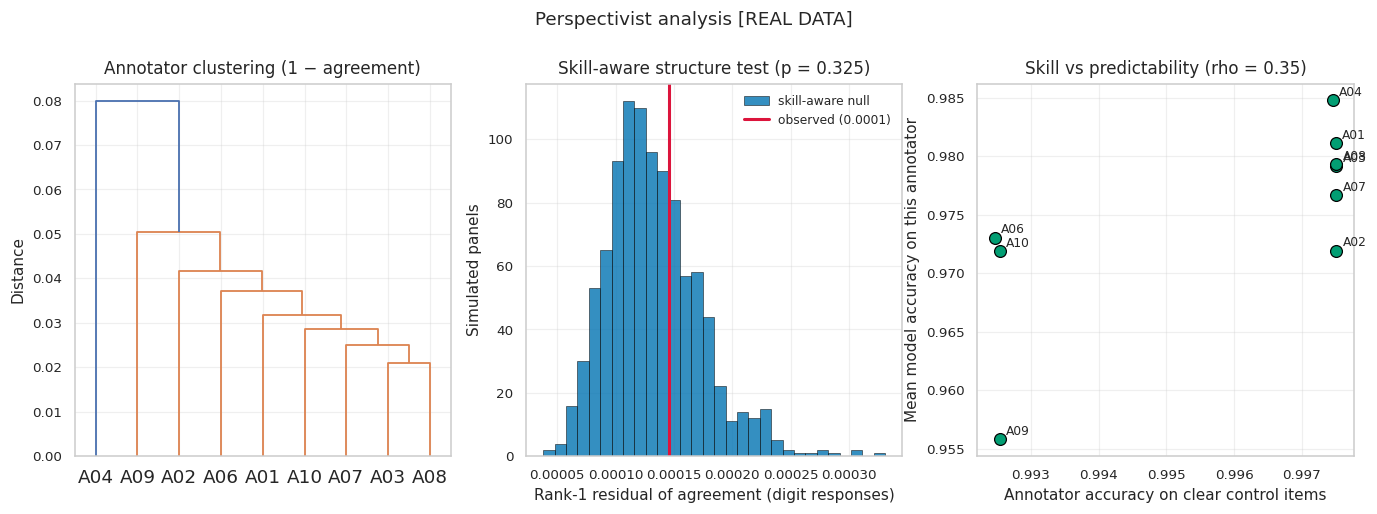

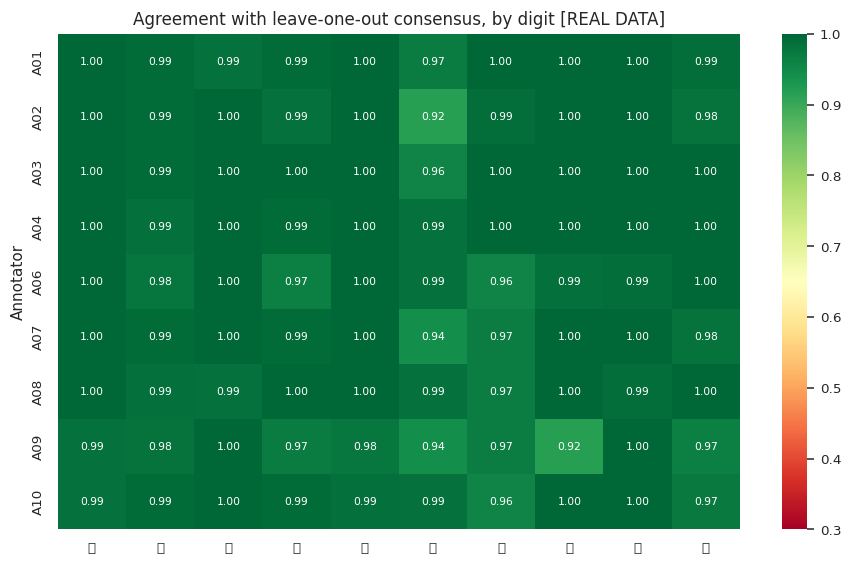

Digits with the most between-annotator variation:
agree_7    0.027
agree_5    0.025
agree_6    0.019
agree_9    0.013


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
Dplot = 1 - A_obs; np.fill_diagonal(Dplot, 0); Dplot = 0.5 * (Dplot + Dplot.T)
Z = linkage(squareform(Dplot, checks=False), method="average")
dendrogram(Z, labels=ANN_IDS, ax=axes[0])
axes[0].set_title("Annotator clustering (1 − agreement)")
axes[0].set_ylabel("Distance")
axes[1].hist(pnull, bins=30, color=PALETTE[0], edgecolor="black", linewidth=0.4,
             alpha=0.8, label="skill-aware null")
axes[1].axvline(obs_res, color="crimson", lw=2, label=f"observed ({obs_res:.4f})")
axes[1].set_xlabel("Rank-1 residual of agreement (digit responses)")
axes[1].set_ylabel("Simulated panels")
axes[1].set_title(f"Skill-aware structure test (p = {P_STRUCT_SKILL:.3f})")
axes[1].legend(fontsize=8)
axes[2].scatter(perspectivist["Control accuracy"], mean_model, s=60, color=PALETTE[2],
                edgecolor="black")
for a, x, y_ in zip(perspectivist.index, perspectivist["Control accuracy"], mean_model):
    axes[2].annotate(a, (x, y_), xytext=(4, 3), textcoords="offset points", fontsize=8)
axes[2].set_xlabel("Annotator accuracy on clear control items")
axes[2].set_ylabel("Mean model accuracy on this annotator")
axes[2].set_title(f"Skill vs predictability (rho = {rho_skill:.2f})")
fig.suptitle(f"Perspectivist analysis [{MODE}]", y=1.03, fontsize=12)
savefig(fig, "sfig10_perspectivist")
plt.show()

bias_rows = []
for a_i, aid in enumerate(ANN_IDS):
    r = R_full[leg_rows, a_i]
    others = np.delete(R_full[leg_rows], a_i, axis=1)
    loo = np.array([np.bincount(o[(o >= 0) & (o < 10)], minlength=10).argmax()
                    if ((o >= 0) & (o < 10)).any() else -1 for o in others])
    ok_ = (r >= 0) & (r < 10) & (loo >= 0)
    cm = confusion_matrix(loo[ok_], r[ok_], labels=range(10))
    recd = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
    bias_rows.append({"Annotator": aid, **{f"agree_{d}": recd[d] for d in range(10)}})
bias = pd.DataFrame(bias_rows).set_index("Annotator")
bias.round(3).to_csv(Path(CFG.tables_dir) / "table_annotator_bias.csv")
fig, ax = plt.subplots(figsize=(10, 0.45 * len(bias) + 1.8))
sns.heatmap(bias, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0.3, vmax=1.0, ax=ax,
            annot_kws={"fontsize": 7}, xticklabels=BANGLA_DIGITS)
ax.set_title(f"Agreement with leave-one-out consensus, by digit [{MODE}]")
savefig(fig, "sfig11_annotator_bias")
plt.show()
print("Digits with the most between-annotator variation:")
print(bias.std(axis=0).sort_values(ascending=False).head(4).round(3).to_string())

## 10. Annotation Saturation

Random sub-panels of $k$ annotators are drawn, and the study's quantities are recomputed with **the same estimators as the headline results**. The item set is held fixed to the full-panel legible items, so only panel size varies.

The table reports the smallest $k$ whose mean lands within tolerance of the full-panel value. One caveat: sub-panels overlap the full panel, so convergence toward the full panel is optimistic at large $k$.

[REAL DATA]  Saturation (reps per k = 50)

   A_cons  C_annot   alpha  ambiguous_share  jsd_to_full  mode_agreement
k                                                                       
2  0.9931   0.9958  0.9533           0.0000       0.0046          0.9903
3  0.9961   0.9952  0.9504           0.0001       0.0032          0.9942
4  0.9964   0.9951  0.9507           0.0014       0.0023          0.9954
5  0.9969   0.9949  0.9487           0.0025       0.0015          0.9972
6  0.9970   0.9949  0.9501           0.0037       0.0011          0.9981
7  0.9971   0.9947  0.9489           0.0048       0.0006          0.9986
8  0.9971   0.9946  0.9487           0.0058       0.0002          0.9993
9  0.9972   0.9947  0.9490           0.0066       0.0000          1.0000

                 Full-panel value  Tolerance  Annotators needed
Metric                                                         
A_cons                     0.9972      0.005                  2
C_annot                    0.9947 

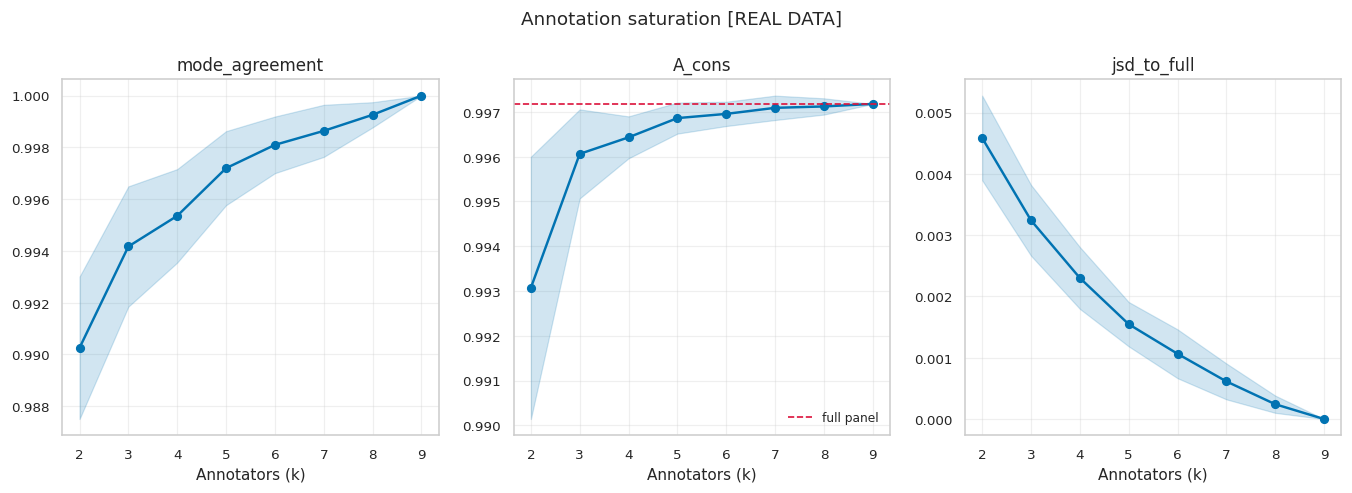

In [29]:
def panel_quantities(cols):
    Rs = R_full[:, cols]
    dig = np.where((Rs >= 0) & (Rs < 10), Rs, -1)
    cnt = np.stack([(dig == c).sum(1) for c in range(10)], 1)[leg_rows].astype(float)
    nd = cnt.sum(1)
    ok_ = nd > 0
    q = np.where(ok_[:, None], cnt / np.maximum(nd, 1)[:, None], np.nan)
    mx = cnt.max(1)
    ek = soft["ekush_label"].to_numpy()[leg_rows]
    tied = cnt == mx[:, None]
    support = np.where(tied[np.arange(len(ek)), ek], 1.0 / tied.sum(1), 0.0)
    st = soft["stratum"].to_numpy()[leg_rows]
    out = {
        "A_cons": strat_bootstrap(np.where(ok_, support, np.nan), st, B=1)[0],
        "C_annot": strat_bootstrap(np.where(ok_, mx / np.maximum(nd, 1), np.nan), st, B=1)[0],
        "alpha": alpha_from_counts(np.stack([(Rs[leg_rows] == i).sum(1)
                                             for i in range(len(RESP_CATS))], 1).astype(float)),
        "ambiguous_share": strat_bootstrap(
            np.where(ok_, (nd - mx) > CFG.unambiguous_max_dissent, np.nan).astype(float), st, B=1)[0],
        "jsd_to_full": float(np.nanmean(js_div(Qh[ok_], q[ok_]))),
        "mode_agreement": float(np.mean(cnt[ok_].argmax(1) ==
                                        leg["human_mode"].to_numpy()[ok_])),
    }
    return out

rs = np.random.RandomState(CFG.stats_seed)
sat_rows = []
for k in range(2, K_ANN + 1):
    for b in range(CFG.saturation_reps if k < K_ANN else 1):
        cols = np.sort(rs.choice(K_ANN, size=k, replace=False)) if k < K_ANN else np.arange(K_ANN)
        sat_rows.append({"k": k, "rep": b, **panel_quantities(cols)})
sat = pd.DataFrame(sat_rows)
full = sat[sat["k"] == K_ANN].iloc[0]
TOL = {"A_cons": 0.005, "C_annot": 0.01, "alpha": 0.05, "ambiguous_share": 0.02,
       "jsd_to_full": 0.02, "mode_agreement": 0.02}
rec_rows = []
for metric, tol in TOL.items():
    target = 0.0 if metric == "jsd_to_full" else (1.0 if metric == "mode_agreement" else full[metric])
    g = sat.groupby("k")[metric].mean()
    within = [k for k in g.index if abs(g[k] - target) <= tol]
    rec_rows.append({"Metric": metric, "Full-panel value": round(float(full[metric]), 4),
                     "Tolerance": tol,
                     "Annotators needed": min(within) if within else f">{K_ANN}"})
saturation_rec = pd.DataFrame(rec_rows).set_index("Metric")
print(f"[{MODE}]  Saturation (reps per k = {CFG.saturation_reps})\n")
print(sat.groupby("k")[list(TOL)].mean().round(4).to_string())
print()
print(saturation_rec.to_string())
saturation_rec.to_csv(Path(CFG.tables_dir) / "table_saturation.csv")
sat.to_csv(Path(CFG.tables_dir) / "saturation_raw.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, metric in zip(axes, ["mode_agreement", "A_cons", "jsd_to_full"]):
    g = sat.groupby("k")[metric]
    mu, sd = g.mean(), g.std().fillna(0)
    ax.plot(mu.index, mu.values, "o-", color=PALETTE[0], lw=1.6, ms=5)
    ax.fill_between(mu.index, mu - sd, mu + sd, color=PALETTE[0], alpha=0.18)
    if metric == "A_cons":
        ax.axhline(full[metric], ls="--", color="crimson", lw=1.1, label="full panel")
        ax.legend(fontsize=8)
    ax.set_xlabel("Annotators (k)"); ax.set_title(metric)
fig.suptitle(f"Annotation saturation [{MODE}]", y=1.03, fontsize=12)
savefig(fig, "sfig12_saturation")
plt.show()

## 11. Agreement-Conditioned Benchmarking

Each model is evaluated separately on high-agreement (`unambiguous`) and low-agreement (`ambiguous`) items, against the human mode. This tests whether any architectural advantage survives outside the easy regime. Accuracies and the high–low gap come with bootstrap intervals.

High-agreement items: 975 | low-agreement items: 20

[REAL DATA]  Agreement-conditioned benchmarking

                     High agreement acc        Low agreement acc              Gap (pp)  Low agreement JSD  Params (M)
Model                                                                                                                
xception        0.9887 [0.9815, 0.9949]  0.7000 [0.5000, 0.9000]   28.87 [9.08, 49.18]           0.113431   20.881970
resnet50v2      0.9928 [0.9867, 0.9979]  0.8000 [0.6000, 0.9500]   19.28 [4.18, 38.98]           0.115990   23.585290
mobilenetv2     0.9918 [0.9856, 0.9969]  0.7000 [0.5000, 0.9000]   29.18 [9.18, 49.28]           0.123372    2.270794
efficientnetb0  0.9764 [0.9662, 0.9856]  0.6500 [0.4500, 0.8500]  32.64 [12.64, 53.05]           0.164119    4.062381
custom_cnn      0.9867 [0.9795, 0.9928]  0.6500 [0.4500, 0.8500]  33.67 [13.56, 53.87]           0.142121    0.289066
ENSEMBLE MEAN   0.9949 [0.9897, 0.9990]  0.7500 [0.5500, 0.9000]   24.49

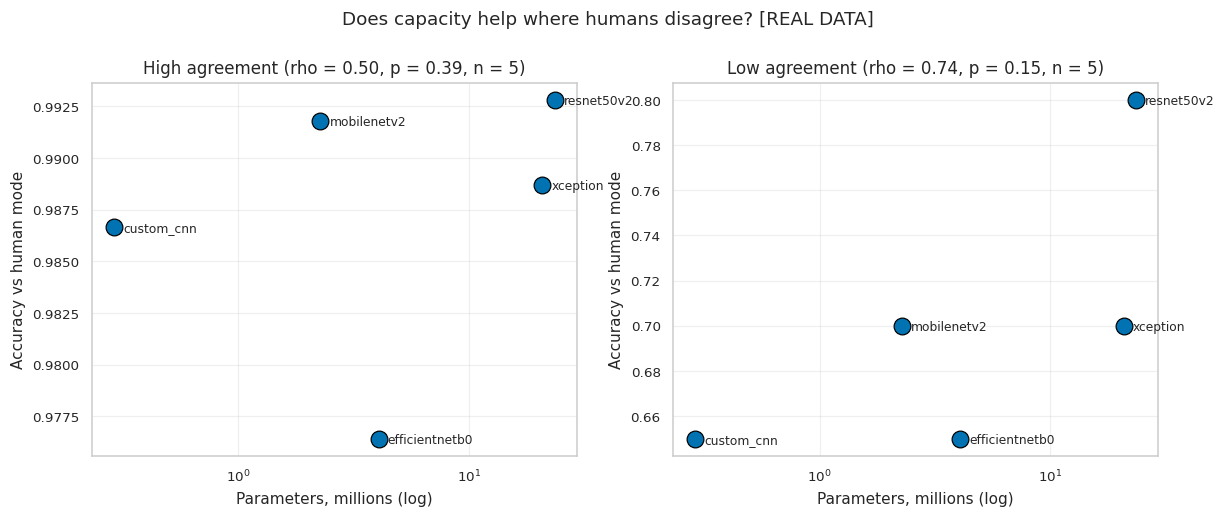

With only 5 models these correlations are descriptive, not inferential.


In [30]:
hi_mask, lo_mask = cat == "unambiguous", cat == "ambiguous"
print(f"High-agreement items: {hi_mask.sum()} | low-agreement items: {lo_mask.sum()}")
rs = np.random.RandomState(CFG.stats_seed + 7)
bh = rs.randint(0, max(hi_mask.sum(), 1), (CFG.n_bootstrap_rank, hi_mask.sum()))
bl = rs.randint(0, max(lo_mask.sum(), 1), (CFG.n_bootstrap_rank, lo_mask.sum()))
cond_rows = []
for t in MODELS_PLUS:
    ma = per_item[t]["Mode accuracy"]
    h, l = ma[hi_mask], ma[lo_mask]
    rec = {"Model": t}
    if len(h) and len(l):
        bhv, blv = h[bh].mean(1), l[bl].mean(1)
        rec.update({
            "High agreement acc": fmt_ci(h.mean(), *np.percentile(bhv, [2.5, 97.5]), 4),
            "Low agreement acc": fmt_ci(l.mean(), *np.percentile(blv, [2.5, 97.5]), 4),
            "Gap (pp)": fmt_ci(100 * (h.mean() - l.mean()),
                               *np.percentile(100 * (bhv - blv), [2.5, 97.5]), 2),
            "Low agreement JSD": per_item[t]["JSD"][lo_mask].mean(),
            "_hi": h.mean(), "_lo": l.mean()})
    rec["Params (M)"] = member_test_acc.loc[t, "Params (M)"]
    cond_rows.append(rec)
conditioned = pd.DataFrame(cond_rows).set_index("Model")
print(f"\n[{MODE}]  Agreement-conditioned benchmarking\n")
print(conditioned.drop(columns=["_hi", "_lo"], errors="ignore").to_string())
conditioned.drop(columns=["_hi", "_lo"], errors="ignore").to_csv(
    Path(CFG.tables_dir) / "table_agreement_conditioned.csv")

COND_RHO = np.nan
if "_hi" in conditioned and conditioned["_hi"].nunique() > 1 and conditioned["_lo"].nunique() > 1:
    COND_RHO = float(stats.spearmanr(conditioned.loc[MEMBERS, "_hi"],
                                     conditioned.loc[MEMBERS, "_lo"])[0])
    print(f"\nSpearman rho between high- and low-agreement rankings: {COND_RHO:.3f}")
else:
    print("\nOne condition is saturated (all models tied); rank correlation undefined.")

d = conditioned.loc[MEMBERS].dropna(subset=["Params (M)"])
if "_hi" in d and len(d) >= 3:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
    for col, ax, name in [("_hi", axes[0], "High agreement"), ("_lo", axes[1], "Low agreement")]:
        ax.scatter(d["Params (M)"], d[col], s=120, color=PALETTE[0], edgecolor="black", zorder=3)
        for m_, r_ in d.iterrows():
            ax.annotate(m_, (r_["Params (M)"], r_[col]), textcoords="offset points",
                        xytext=(6, -3), fontsize=8)
        rr, pp = stats.spearmanr(d["Params (M)"], d[col])
        ax.set_xscale("log"); ax.set_title(f"{name} (rho = {rr:.2f}, p = {pp:.2f}, n = {len(d)})")
        ax.set_xlabel("Parameters, millions (log)"); ax.set_ylabel("Accuracy vs human mode")
    fig.suptitle(f"Does capacity help where humans disagree? [{MODE}]", y=1.03, fontsize=12)
    savefig(fig, "sfig13_capacity_by_condition")
    plt.show()
    print(f"With only {len(d)} models these correlations are descriptive, not inferential.")

## 12. Soft-Label Training (cross-validated)

The headline architecture's first-seed checkpoint from Notebook 1 (hash-verified) is fine-tuned on the annotated items under three targets:

1. hard Ekush labels;
2. the hard human mode;
3. the soft human distribution.

The design is **5-fold cross-validation × 3 seeds**, stratified by human mode. Every item is evaluated exactly once per seed, by a model that never saw it during fine-tuning. The base model was trained on the train split and has never seen these test images.

Out-of-fold predictions are averaged over seeds. Differences between targets are reported with **paired bootstrap** intervals over items. With about 1,000 items the analysis can detect calibration and distributional effects; it is not designed to establish accuracy gains.

Loaded verified checkpoint xception_s13.keras for fine-tuning.
  seed 13 fold 1/5 done (3 fits reused from Drive, 0 new)
  seed 13 fold 2/5 done (6 fits reused from Drive, 0 new)
  seed 13 fold 3/5 done (9 fits reused from Drive, 0 new)
  seed 13 fold 4/5 done (12 fits reused from Drive, 0 new)
  seed 13 fold 5/5 done (15 fits reused from Drive, 0 new)
  seed 42 fold 1/5 done (18 fits reused from Drive, 0 new)
  seed 42 fold 2/5 done (21 fits reused from Drive, 0 new)
  seed 42 fold 3/5 done (24 fits reused from Drive, 0 new)
  seed 42 fold 4/5 done (27 fits reused from Drive, 0 new)
  seed 42 fold 5/5 done (30 fits reused from Drive, 0 new)
  seed 2024 fold 1/5 done (33 fits reused from Drive, 0 new)
  seed 2024 fold 2/5 done (36 fits reused from Drive, 0 new)
  seed 2024 fold 3/5 done (39 fits reused from Drive, 0 new)
  seed 2024 fold 4/5 done (42 fits reused from Drive, 0 new)
  seed 2024 fold 5/5 done (42 fits reused from Drive, 3 new)

[REAL DATA]  Training target, mean ± sd over

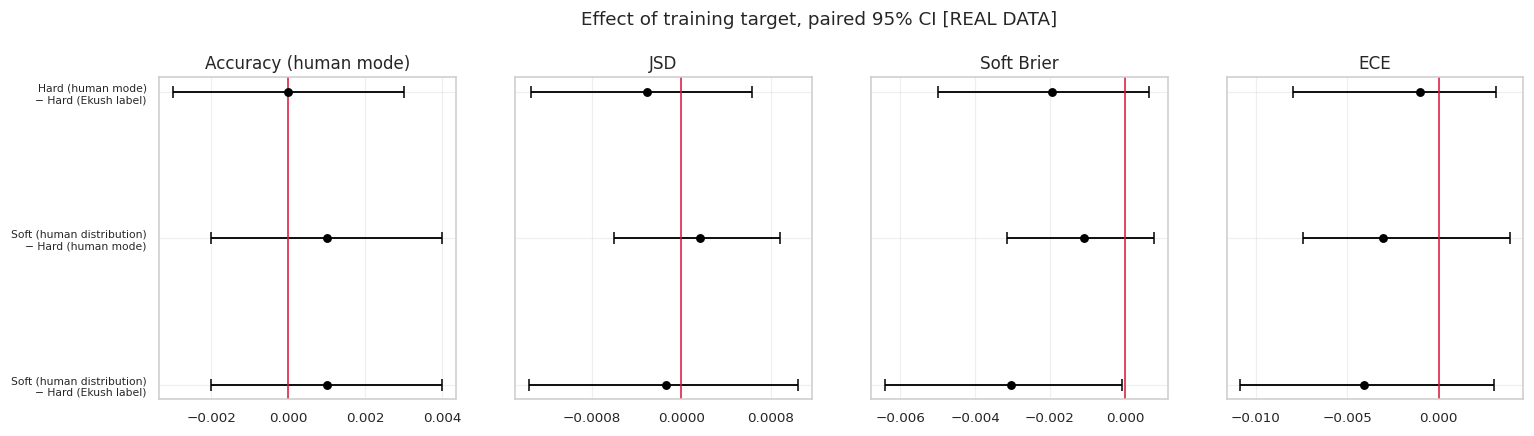

In [31]:
import gc
PREPROC = {"raw": lambda x: x}
ENSEMBLE = {}
if CFG.run_soft_training:
    r0 = runs[runs["arch"] == HEADLINE_TAG].sort_values("seed").iloc[0]
    ck = Path(CFG.models_dir) / r0["checkpoint"]
    if not ck.is_file():
        fail(f"Checkpoint {ck} not found. Point models_dir at Notebook 1's models "
             "folder, or set run_soft_training=False to skip this section deliberately.")
    elif sha256_file(ck) != r0["checkpoint_sha256"]:
        fail(f"Checkpoint {ck.name} does not match the hash recorded in the package.")
    else:
        ENSEMBLE[HEADLINE_TAG] = {"model": keras.models.load_model(ck), "img_size": (28, 28),
                                  "channels": 1, "preproc": "raw", "logits": False}
        print(f"Loaded verified checkpoint {ck.name} for fine-tuning.")

softtrain, softtrain_diff = None, None
if CFG.run_soft_training and HEADLINE_TAG in ENSEMBLE:
    base = ENSEMBLE[HEADLINE_TAG]
    model = base["model"]                     # ONE model, reused for every fit
    init_weights = model.get_weights()        # includes BatchNorm statistics
    tr_items = leg.reset_index(drop=True)

    def frame_to_array(paths, spec):
        X = np.zeros((len(paths), *spec["img_size"], spec["channels"]), dtype=np.float32)
        for i, fp in enumerate(paths):
            im = Image.open(fp).convert("RGB" if spec["channels"] == 3 else "L")
            a = np.asarray(im.resize(spec["img_size"][::-1], Image.BILINEAR), dtype=np.float32)
            X[i] = PREPROC[spec["preproc"]](a[..., None] if spec["channels"] == 1 else a)
        return X

    X_all = frame_to_array(tr_items["filepath"], base)
    Q_all = _norm(tr_items[Q_COLS].to_numpy(float))
    y_mode = tr_items["human_mode"].to_numpy()
    y_ek = tr_items["ekush_label"].to_numpy()
    TARGETS = {"Hard (Ekush label)": np.eye(10)[y_ek],
               "Hard (human mode)": np.eye(10)[y_mode],
               "Soft (human distribution)": Q_all}
    min_class = np.bincount(y_mode, minlength=10)
    use_strat = min_class[min_class > 0].min() >= CFG.soft_cv_folds
    loss = keras.losses.CategoricalCrossentropy(from_logits=base.get("logits", False))

    # Every finished fit is saved to Drive; a crashed session resumes here.
    SOFT_DIR = Path(CFG.output_dir) / "soft_training"
    SOFT_DIR.mkdir(parents=True, exist_ok=True)
    fingerprint = hashlib.sha256(json.dumps({
        "items": tr_items["item_uid"].tolist(), "q": np.round(Q_all, 6).tolist(),
        "checkpoint": r0["checkpoint_sha256"], "folds": CFG.soft_cv_folds,
        "epochs": CFG.soft_epochs, "lr": CFG.soft_lr, "batch": CFG.soft_batch,
    }).encode()).hexdigest()[:16]
    meta_path = SOFT_DIR / "meta.json"
    if meta_path.is_file() and json.loads(meta_path.read_text()).get("fingerprint") != fingerprint:
        print("Saved fits belong to different data or settings; starting fresh.")
        for f_ in SOFT_DIR.glob("*.npz"):
            f_.unlink()
    meta_path.write_text(json.dumps({"fingerprint": fingerprint}))
    slug = {"Hard (Ekush label)": "hard_ekush", "Hard (human mode)": "hard_mode",
            "Soft (human distribution)": "soft"}

    oof = {t: np.zeros((len(CFG.soft_seeds), len(tr_items), 10)) for t in TARGETS}
    n_done = n_new = 0
    for si, seed in enumerate(CFG.soft_seeds):
        splitter = (StratifiedKFold(CFG.soft_cv_folds, shuffle=True, random_state=seed)
                    if use_strat else KFold(CFG.soft_cv_folds, shuffle=True, random_state=seed))
        for fi, (tr_i, te_i) in enumerate(splitter.split(X_all, y_mode)):
            for tname, T in TARGETS.items():
                fp = SOFT_DIR / f"s{seed}_f{fi}_{slug[tname]}.npz"
                if fp.is_file():
                    z = np.load(fp)
                    if np.array_equal(z["te_i"], te_i):
                        oof[tname][si, te_i] = z["pred"]
                        n_done += 1
                        continue
                set_seed(seed * 100 + fi)
                model.set_weights(init_weights)                       # reset, no clone
                model.compile(optimizer=keras.optimizers.Adam(CFG.soft_lr), loss=loss)
                model.fit(X_all[tr_i], T[tr_i], epochs=CFG.soft_epochs,
                          batch_size=CFG.soft_batch, validation_split=0.15, verbose=0,
                          callbacks=[keras.callbacks.EarlyStopping(
                              monitor="val_loss", patience=4, restore_best_weights=True)])
                pr = np.asarray(model.predict(X_all[te_i], batch_size=256, verbose=0),
                                dtype=np.float64)
                if base.get("logits", False):
                    pr = tf.nn.softmax(pr).numpy()
                pr = _norm(pr)
                oof[tname][si, te_i] = pr
                np.savez_compressed(fp, pred=pr, te_i=te_i)
                n_new += 1
                gc.collect()
            print(f"  seed {seed} fold {fi + 1}/{CFG.soft_cv_folds} done "
                  f"({n_done} fits reused from Drive, {n_new} new)")
    model.set_weights(init_weights)

    msets = [mode_sets[i] for i in range(len(leg))]
    def target_metrics(Pp):
        return {"Accuracy (human mode)": np.array([p in s for p, s in zip(Pp.argmax(1), msets)], float),
                "JSD": js_div(Q_all, Pp), "Soft Brier": soft_brier(Q_all, Pp),
                "NLL (human dist.)": cross_entropy_to(Q_all, Pp),
                "Mean confidence": Pp.max(1)}

    rows = []
    for tname in TARGETS:
        per_seed = [target_metrics(oof[tname][si]) for si in range(len(CFG.soft_seeds))]
        rec = {"Target": tname}
        for k_ in per_seed[0]:
            v = [ps[k_].mean() for ps in per_seed]
            rec[k_] = f"{np.mean(v):.4f} ± {np.std(v):.4f}"
        e = [ece(y_mode, oof[tname][si]) for si in range(len(CFG.soft_seeds))]
        rec["ECE"] = f"{np.mean(e):.4f} ± {np.std(e):.4f}"
        rows.append(rec)
    softtrain = pd.DataFrame(rows).set_index("Target")
    print(f"\n[{MODE}]  Training target, mean ± sd over {len(CFG.soft_seeds)} seeds "
          f"(out-of-fold, n = {len(tr_items)})\n")
    print(softtrain.to_string())

    avg = {t: _norm(oof[t].mean(0)) for t in TARGETS}
    mets = {t: target_metrics(avg[t]) for t in TARGETS}
    bidx = boot_index_sets(tr_items["stratum"].to_numpy(), CFG.n_bootstrap_rank, CFG.stats_seed + 3)
    comparisons = [("Soft (human distribution)", "Hard (Ekush label)"),
                   ("Soft (human distribution)", "Hard (human mode)"),
                   ("Hard (human mode)", "Hard (Ekush label)")]
    drows = []
    for a, b in comparisons:
        for k_ in ["Accuracy (human mode)", "JSD", "Soft Brier", "NLL (human dist.)"]:
            dlt = mets[a][k_] - mets[b][k_]
            bs = dlt[bidx].mean(1)
            lo, hi = np.percentile(bs, [2.5, 97.5])
            drows.append({"Comparison": f"{a} − {b}", "Metric": k_,
                          "Difference": dlt.mean(), "CI low": lo, "CI high": hi,
                          "Excludes 0": bool(lo > 0 or hi < 0)})
        bs = [ece(y_mode[i], avg[a][i]) - ece(y_mode[i], avg[b][i]) for i in bidx[:500]]
        pt = ece(y_mode, avg[a]) - ece(y_mode, avg[b])
        lo, hi = np.percentile(bs, [2.5, 97.5])
        drows.append({"Comparison": f"{a} − {b}", "Metric": "ECE", "Difference": pt,
                      "CI low": lo, "CI high": hi, "Excludes 0": bool(lo > 0 or hi < 0)})
    softtrain_diff = pd.DataFrame(drows)
    print("\nPaired bootstrap differences (seed-averaged predictions):\n")
    print(softtrain_diff.round(4).to_string(index=False))
    softtrain.to_csv(Path(CFG.tables_dir) / "table_soft_label_training.csv")
    softtrain_diff.round(5).to_csv(Path(CFG.tables_dir) / "table_soft_label_training_diff.csv",
                                   index=False)

    fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
    for ax, k_ in zip(axes, ["Accuracy (human mode)", "JSD", "Soft Brier", "ECE"]):
        sub = softtrain_diff[softtrain_diff["Metric"] == k_]
        yy = np.arange(len(sub))
        ax.errorbar(sub["Difference"], yy, xerr=[sub["Difference"] - sub["CI low"],
                                                  sub["CI high"] - sub["Difference"]],
                    fmt="o", color="black", capsize=4)
        ax.axvline(0, color="crimson", lw=1)
        ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(4))
        ax.set_yticks(yy)
        ax.set_yticklabels([c.replace(" − ", "\n− ") for c in sub["Comparison"]] if ax is axes[0]
                           else [""] * len(yy), fontsize=7)
        ax.set_title(k_)
    fig.suptitle(f"Effect of training target, paired 95% CI [{MODE}]", y=1.04, fontsize=12)
    savefig(fig, "sfig14_soft_label_training")
    plt.show()
else:
    print("Soft-label training skipped.")

## 13. Release Artifacts, Tables, and Manifest

In [32]:
release = soft.copy()
release["ekush_file"] = release["filepath"].map(lambda p: Path(p).name)
release["ekush_class_dir"] = release["filepath"].map(lambda p: Path(p).parent.name)
release_cols = (["ekush_file", "ekush_class_dir", "item_uid", "stratum", "ekush_label",
                 "n_annotators", "n_digit_votes", "n_illegible", "n_not_digit"]
                + [f"votes_{c}" for c in DIGIT_CLASSES] + Q_COLS
                + ["human_mode", "mode_tied", "human_max_share", "human_entropy",
                   "illegible_rate", "guess_rate"]
                + [f"wmv_{c}" for c in range(10)]
                + ["wmv_max", "noise_p", "category", "category_unanimous", "category_noise"])
release[release_cols].to_csv(Path(CFG.release_dir) / "ekush_digits_soft_labels.csv", index=False)

ann_rel = raw_annot.merge(release[["item_uid", "ekush_file", "ekush_class_dir"]],
                          on="item_uid", how="left")
ann_rel["annotator_excluded"] = ann_rel["annotator_id"].isin(excluded)
ann_rel[["annotator_id", "annotator_excluded", "item_uid", "ekush_file", "ekush_class_dir",
         "stratum", "repeat", "presentation_index", "response", "confidence",
         "response_ms"]].to_csv(Path(CFG.release_dir) / "ekush_digits_annotator_level.csv",
                                index=False)
np.savetxt(Path(CFG.release_dir) / "digit_confusion_cost.csv", D_COST, delimiter=",", fmt="%.6f")
shutil.copy(Path(CFG.frozen_dir) / "preregistration.json", Path(CFG.release_dir))
pd.DataFrame({"control_accuracy": NOISE_ACC, "error_rate": NOISE_ERR}).rename_axis(
    "annotator_id").to_csv(Path(CFG.release_dir) / "annotator_noise_rates.csv")
print("Release files:", sorted(p.name for p in Path(CFG.release_dir).iterdir()))


def to_latex_simple(df, caption, label):
    cols = [str(c) for c in df.columns]
    esc = lambda s: (str(s).replace("\\", r"\textbackslash{}").replace("_", r"\_")
                     .replace("%", r"\%").replace("&", r"\&").replace("#", r"\#")
                     .replace("±", r"$\pm$").replace("−", "--"))
    fmt = lambda v: f"{v:.4f}" if isinstance(v, (float, np.floating)) else esc(v)
    lines = [r"\begin{table}[t]", r"\centering", r"\small",
             rf"\caption{{{esc(caption)}}}", rf"\label{{{label}}}",
             r"\resizebox{\linewidth}{!}{%",
             r"\begin{tabular}{l" + "c" * len(cols) + "}", r"\toprule",
             " & ".join([esc(df.index.name or "")] + [esc(c) for c in cols]) + r" \\",
             r"\midrule"]
    for idx, row in df.iterrows():
        lines.append(" & ".join([esc(idx)] + [fmt(v) for v in row.values]) + r" \\")
    lines += [r"\bottomrule", r"\end{tabular}}", r"\end{table}"]
    return "\n".join(lines)

stamp = "" if not SIMULATED else " [SIMULATED -- NOT PUBLISHABLE]"
latex_tables = {
    "member_test_accuracy": (member_test_acc.round(4), "Full test-split accuracy (Wilson 95\\% CI)"),
    "reliability": (reliability.drop(columns=["reason"]).round(3), "Annotator reliability and exclusion"),
    "taxonomy": (tax, "Item taxonomy by stratum"),
    "taxonomy_sensitivity": (sens, "Sensitivity of the ambiguity rate to the ambiguity rule"),
    "ceiling": (ceiling_df[["Estimate (%)", "95% CI low", "95% CI high"]],
                "Corpus-level human support for the Ekush labels"),
    "ranking": (show.pivot(index="Model", columns="Regime", values="Accuracy"),
                "Accuracy by scoring regime, mean [95% CI]"),
    "soft_metrics": (softmetrics_ci, "Distributional metrics against human labels, mean [95% CI]"),
    "perspectivist": (perspectivist.round(3), "Predicting individual annotators"),
    "saturation": (saturation_rec, "Annotators needed per quantity"),
    "agreement_conditioned": (conditioned.drop(columns=["_hi", "_lo"], errors="ignore"),
                              "Accuracy by agreement condition"),
}
if softtrain is not None:
    latex_tables["soft_label_training"] = (softtrain, "Effect of the training target (mean $\\pm$ sd over seeds)")
    latex_tables["soft_label_training_diff"] = (
        softtrain_diff.set_index("Comparison").round(4), "Paired differences between training targets")
for name, (df, cap) in latex_tables.items():
    (Path(CFG.tables_dir) / f"{name}.tex").write_text(
        to_latex_simple(df, cap + stamp, f"tab:{name}"))
print(f"LaTeX tables: {len(latex_tables)} written to {CFG.tables_dir}")

Release files: ['ANNOTATOR_PROTOCOL.md', 'DATASHEET.md', 'annotation_tool.html', 'annotator_noise_rates.csv', 'digit_confusion_cost.csv', 'ekush_digits_annotator_level.csv', 'ekush_digits_soft_labels.csv', 'preregistration.json']
LaTeX tables: 12 written to /content/drive/MyDrive/ekush_study/human_study/tables


In [33]:
datasheet = f"""# Ekush-Digits-Soft — human label distributions for ambiguous Bangla numerals

Status: **{MODE}**
Instrument ID: {INSTRUMENT_ID} | Pre-registration SHA-256: {FROZEN['preregistration_sha256']}
Generated: {time.strftime('%Y-%m-%d')}

## Composition
- Items: {len(soft)} from the Ekush numeral test split (SHA-256 {TEST_SPLIT_SHA[:16]}...)
- Strata (population / annotated): {', '.join(f"{s} {STRATUM_POPULATION[s]}/{int((soft['stratum'] == s).sum())}" for s in STRATA)}
- Annotators: {K_ANN} retained of {reliability.shape[0]} (excluded: {', '.join(excluded) or 'none'})
- Judgements (retained, first presentation): {len(annot):,}
- Krippendorff's alpha: {fmt_ci(*alpha_all)} overall; {'; '.join(f'{s} {fmt_ci(*v)}' for s, v in alpha_by.items())}

## Item categories (primary rule)
{soft['category'].value_counts().to_string()}

## Files
- `ekush_digits_soft_labels.csv` — votes, vote shares, reliability-weighted posteriors, noise-test p-values, and categories under three rules.
- `annotator_noise_rates.csv` — per-annotator error rates on clear control items.
- `ekush_digits_annotator_level.csv` — every response, including repeats and excluded annotators (flagged).
- `digit_confusion_cost.csv` — 10x10 ground cost learned from human co-voting.
- `preregistration.json` — thresholds fixed before annotation.
- `annotation_tool.html`, `ANNOTATOR_PROTOCOL.md` — the instrument as distributed.
- Item selection, model predictions and checkpoint hashes: Notebook 1 study package (study ID in the header).

## Collection protocol
Items were ranked by an ensemble ambiguity score (rank average of predictive entropy,
aleatoric entropy, top-2 margin and variation ratio) computed from the Notebook 1
ensemble ({', '.join(MEMBERS)}; all seeds). The test split was partitioned into disjoint
strata: a census of the top {CFG.n_cl_max} confident-learning label-issue candidates (cl),
a census of the next {CFG.n_high} most ambiguous images (high), {CFG.n_mid} sampled from the
following {CFG.mid_pool_size} (mid), and {CFG.n_low} sampled from the remainder (low).
Annotators saw opaque identifiers, no stored label and no model output, in a per-annotator
random order. {len(check_uids)} easy items were repeated
as attention checks. Exclusion rules were pre-registered.

## Recommended use
Report distributional metrics (JSD, soft Brier, cross-entropy, confusion cost) with
confidence intervals, and evaluate high- and low-agreement items separately. Corpus-level
estimates must use the stratum weights; unweighted means describe the annotated sample only.

## Known limitations
- Images are 28x28 in the public redistribution used here; some ambiguity may be a
  resolution artifact.
- Item selection is model-driven; the human distributions are not, and the strata keep
  corpus estimates valid.
- With {K_ANN} annotators the finest vote share is 1/{K_ANN}; item-level distributions are coarse.
- Annotators were not the writers and may not share every regional letterform convention.

## Licence
CC BY 4.0, subject to the Ekush terms of use. Citation: [add on acceptance]
"""
(Path(CFG.release_dir) / "DATASHEET.md").write_text(datasheet)

def _f(x):
    return None if x is None or (isinstance(x, float) and np.isnan(x)) else float(x)

manifest = {
    "mode": MODE, "simulated": bool(SIMULATED),
    "publishable": bool(not SIMULATED and CFG.publication_mode and PANEL_OK),
    "generated_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "instrument_id": INSTRUMENT_ID,
    "preregistration_sha256": FROZEN["preregistration_sha256"],
    "test_split_sha256": TEST_SPLIT_SHA, "split_provenance": SPLIT_PROVENANCE,
    "ensemble_source": ENSEMBLE_SOURCE, "ensemble_members": MEMBERS,
    "member_preprocessing": FROZEN.get("member_preprocessing"),
    "headline_member": HEADLINE_TAG,
    "member_test_accuracy": member_test_acc["Test accuracy"].round(5).to_dict(),
    "stratum_population": STRATUM_POPULATION,
    "n_items": int(len(soft)), "n_legible": int(len(leg)),
    "n_annotators_raw": int(reliability.shape[0]), "n_annotators_retained": K_ANN,
    "excluded_annotators": excluded,
    "krippendorff_alpha": {"overall": list(alpha_all),
                           **{s: list(v) for s, v in alpha_by.items()}},
    "taxonomy_primary": soft["category"].value_counts().to_dict(),
    "taxonomy_sensitivity": sens.to_dict(orient="index"),
    "noise_explained_items": int(soft["noise_explained"].sum()),
    "estimands_pct": ceiling_df[["Estimate (%)", "95% CI low", "95% CI high"]].to_dict(orient="index"),
    "illegible_corpus_share_pct": 100 * illeg_share,
    "model_vs_human_uncertainty_spearman": _f(rho_mh),
    "ranking": {"point_rank_changes": RANK_CHANGES, "top_resolved": top_resolved,
                "significant_pairs": sig.to_dict(orient="index")},
    "soft_metrics_rank_changes": METRIC_RANK_CHANGES, "kendall_w_metrics": KENDALL_W,
    "perspectivist": {"structure_p_exchangeable": P_STRUCT,
                      "structure_p_skill_aware": P_STRUCT_SKILL, "verdict": STRUCT_VERDICT,
                      "test_calibration": (CALIBRATION.reset_index().to_dict(orient="records")
                                           if CALIBRATION is not None else None),
                      "separation": _f(obs_sep),
                      "mantel_skill_rho": _f(mantel_r), "mantel_p": MANTEL_P,
                      "spread": PERSP_SPREAD, "skill_predictability_rho": _f(rho_skill)},
    "saturation": saturation_rec.to_dict(orient="index"),
    "agreement_conditioned_rank_rho": _f(COND_RHO),
    "soft_label_training_diff": (softtrain_diff.to_dict(orient="records")
                                 if softtrain_diff is not None else None),
    "label_issue_candidates": CLP,
    "study_id": INSTRUMENT_ID,
    "preregistration": FROZEN["preregistration"],
}
with open(Path(CFG.output_dir) / "study_manifest.json", "w") as fh:
    json.dump(manifest, fh, indent=2, default=str)

arch_name = "ekush_human_study_results" + ("_SIMULATED_DEBUG" if SIMULATED else "")
archive = shutil.make_archive(str(Path(CFG.drive_root) / arch_name), "zip", CFG.output_dir)
print(f"Results archive: {archive} ({Path(archive).stat().st_size / 1e6:.1f} MB)")
print(f"Publishable: {manifest['publishable']}")
if SIMULATED:
    print("\n" + "!" * 70)
    print("ALL NUMBERS ARE SIMULATED. They test the code only and must not be")
    print("reported, plotted, or described as findings anywhere.")
    print("!" * 70)

Results archive: /content/drive/MyDrive/ekush_study/ekush_human_study_results.zip (6.8 MB)
Publishable: True


## 14. Contributions, Limitations, and Threats to Validity

### Contributions (to be confirmed by the real results)

1. The first human label distributions for an Indic handwriting benchmark, released at annotator level with a datasheet and a pre-registration file.
2. A human-validated precision and recall estimate for confident-learning label-issue detection on a handwriting benchmark.
3. A corpus-level estimate of how far human consensus supports the Ekush labels. It uses partitioned stratified sampling and is directly comparable to published accuracies.
4. Annotator noise separated from image ambiguity, using error rates measured on clear items and a Poisson-binomial consistency test. The result is a bracketed ambiguity rate (lower bound to upper bound) rather than a single rule-dependent number.
5. Model rankings reported with rank uncertainty and multiplicity-corrected pairwise tests.
6. A cross-fitted, corpus-specific confusion cost.
7. A perspectivist structure test with a skill-aware null, so that differences in annotator accuracy are not mistaken for distinct readings.
8. Metric-specific guidance on how many annotators are needed.
9. A cross-validated soft- versus hard-label training comparison.

### Limitations to state in the paper

- **Model-driven selection.** The annotated set over-represents images that *these* checkpoints find hard. The strata keep corpus estimates unbiased, but the precision of corpus estimates is set by the sampled strata, not by all 1,000 items.
- **Annotators are not the writers.** Regional letterform conventions may inflate measured ambiguity, and the perspectivist test cannot attribute any clusters to region without annotator metadata.
- **Coarse resolution.** With about 10 votes per item, item-level distributions are coarse; aggregates over hundreds of items are not.
- **The noise model is a one-coin model.** It assumes an annotator's error rate on hard images equals their rate on clear ones, and that errors are spread evenly across digits. The noise-consistency rule is a lower bound on ambiguity and the vote rules are upper bounds; all three are reported.
- **Resolution.** The public mirror stores 28×28 images, so some ambiguity may be a resolution artifact.
- **Confidence ratings are not calibrated across annotators** and are used descriptively only.
- **Few architectures.** Capacity-versus-agreement analyses with a handful of models are descriptive.
- **Soft-label training** is cross-validated on about 1,000 items. It addresses calibration and distributional fit, not accuracy at training scale.

### Reporting checklist

- [ ] Report `publishable: true` in `study_manifest.json`.
- [ ] Cite the pre-registration hash and the date it was shared.
- [ ] Report A_cons with its CI, alongside member test accuracies with their CIs.
- [ ] Report α by stratum with CIs.
- [ ] Report taxonomy sensitivity under all three rules.
- [ ] Report the ranking table with rank intervals and the count of significant pairs, including when nothing is significant.
- [ ] Report soft metrics with CIs and P(best).
- [ ] Report both structure tests; base any claim about reading conventions only on the skill-aware test.
- [ ] Report soft-training differences as paired CIs; make no accuracy claim unless the CI excludes 0.
- [ ] Report the label-issue candidate precision and recall with CIs.
- [ ] Release the suspected-mislabel list.

## References

[1] Rabby et al., "Ekush: A Multipurpose and Multitype Comprehensive Database for Online Off-Line Bangla Handwritten Characters," RTIP2R, Springer CCIS 1037, 2019.
[2] Peterson, Battleday, Griffiths, Russakovsky, "Human Uncertainty Makes Classification More Robust," ICCV 2019.
[3] Plank, "The 'Problem' of Human Label Variation," EMNLP 2022.
[4] Uma et al., "Learning from Disagreement: A Survey," JAIR 72, 2021.
[5] Nie, Zhou, Bansal, "What Can We Learn from Collective Human Opinions on NLI Data?" EMNLP 2020.
[6] Leonardelli et al., "SemEval-2023 Task 11: Learning with Disagreements," SemEval 2023.
[7] Dawid and Skene, "Maximum Likelihood Estimation of Observer Error-Rates Using the EM Algorithm," J. Royal Statistical Society C, 28(1), 1979. (Motivates the noise model; see section 7 for why the unsupervised version was not used.)
[8] Krippendorff, Content Analysis, 4th ed., Sage, 2018.
[9] Northcutt, Athalye, Mueller, "Pervasive Label Errors in Test Sets Destabilize Machine Learning Benchmarks," NeurIPS Datasets and Benchmarks 2021.
[10] Gebru et al., "Datasheets for Datasets," CACM 2021.
[11] Prabhakaran, Davani, Diaz, "On Releasing Annotator-Level Labels and Information in Datasets," LAW 2021.
[12] Holm, "A Simple Sequentially Rejective Multiple Test Procedure," Scandinavian J. Statistics 6(2), 1979.
[14] Northcutt, Jiang, Chuang, "Confident Learning: Estimating Uncertainty in Dataset Labels," JAIR 70, 2021.
[13] Mantel, "The Detection of Disease Clustering and a Generalized Regression Approach," Cancer Research 27(2), 1967.

*Verify every reference against the original before submission.*